In [1]:
# ============================================================
# CELL 1-A: Standard Library, Sklearn, Optuna, Imbalanced-Learn
# ============================================================
import random
import warnings

# Reproducibility seeds — set FIRST before any random ops
random.seed(42)

try:
    import numpy as np
    np.random.seed(42)
    print(f"numpy          {np.__version__}")
except ImportError as e:
    print(f"[ERROR] numpy: {e}")

try:
    import pandas as pd
    pd.set_option('display.max_columns', 50)
    print(f"pandas         {pd.__version__}")
except ImportError as e:
    print(f"[ERROR] pandas: {e}")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_style('whitegrid')
    # NOTE: no global plt.rcParams override — figsize set per plot
    print(f"matplotlib     {plt.matplotlib.__version__}")
    print(f"seaborn        {sns.__version__}")
except ImportError as e:
    print(f"[ERROR] matplotlib/seaborn: {e}")

try:
    import sklearn
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.feature_selection import (
        VarianceThreshold, mutual_info_classif,
        RFE, SelectKBest
    )
    from sklearn.ensemble import (
        RandomForestClassifier, GradientBoostingClassifier,
        IsolationForest
    )
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.decomposition import PCA, TruncatedSVD
    from sklearn.manifold import TSNE
    from sklearn.model_selection import (
        train_test_split, StratifiedKFold,
        cross_val_score, GridSearchCV
    )
    from sklearn.metrics import (
        classification_report, confusion_matrix,
        precision_score, recall_score, f1_score,
        roc_auc_score, roc_curve,
        average_precision_score, matthews_corrcoef
    )
    from sklearn.metrics.pairwise import euclidean_distances
    print(f"scikit-learn   {sklearn.__version__}")
except ImportError as e:
    print(f"[ERROR] scikit-learn: {e}")

try:
    import imblearn
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    print(f"imbalanced-learn {imblearn.__version__}")
except ImportError as e:
    print(f"[ERROR] imbalanced-learn: {e}")

try:
    import optuna
    from optuna.samplers import TPESampler
    print(f"optuna         {optuna.__version__}")
except ImportError as e:
    print(f"[ERROR] optuna: {e}")

try:
    from scipy import stats
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.stats import mannwhitneyu
    import scipy
    print(f"scipy          {scipy.__version__}")
except ImportError as e:
    print(f"[ERROR] scipy: {e}")

warnings.filterwarnings('ignore')
print("\n[OK] Cell 1-A complete — standard library + sklearn loaded.")


numpy          2.4.6
pandas         3.0.3
matplotlib     3.11.0
seaborn        0.13.2
scikit-learn   1.9.0
imbalanced-learn 0.14.2
optuna         4.9.0
scipy          1.17.1

[OK] Cell 1-A complete — standard library + sklearn loaded.


In [2]:
# ============================================================
# CELL 1-B: Gradient Boosting Libraries
# ============================================================
try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    print(f"xgboost        {xgb.__version__}")
except ImportError as e:
    print(f"[ERROR] xgboost: {e}")

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    print(f"lightgbm       {lgb.__version__}")
except ImportError as e:
    print(f"[ERROR] lightgbm: {e}")

try:
    import catboost
    from catboost import CatBoostClassifier
    print(f"catboost       {catboost.__version__}")
except ImportError as e:
    print(f"[ERROR] catboost: {e}")

print("\n[OK] Cell 1-B complete — GBDT libraries loaded.")


xgboost        3.2.0
lightgbm       4.6.0
catboost       1.2.10

[OK] Cell 1-B complete — GBDT libraries loaded.


In [3]:
# ============================================================
# CELL 1-C: Dimensionality Reduction & Explainability
# ============================================================
try:
    import umap
    print(f"umap-learn     {umap.__version__}")
except ImportError as e:
    print(f"[ERROR] umap-learn: {e}")

try:
    import shap
    print(f"shap           {shap.__version__}")
except ImportError as e:
    print(f"[ERROR] shap: {e}")

print("\n[OK] Cell 1-C complete — UMAP + SHAP loaded.")


umap-learn     0.5.12
shap           0.52.0

[OK] Cell 1-C complete — UMAP + SHAP loaded.


In [4]:

df = pd.read_csv('DataSet.csv')
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

# Drop identifier column if exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("Dropped 'Unnamed: 0' column")

# ── DECISION GATE 1: Assert target column exists ──────────────────────────────
assert 'F3924' in df.columns, (
    "Target column 'F3924' is missing from the dataset. "
    "Check that the correct CSV was loaded and the column was not dropped."
)

# Separate features and target
target_col = 'F3924'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nDataset Info:")
print(f"  Shape         : {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"  Features      : {X.shape[1]:,}")

# ── DECISION GATE 2: Class balance as percentages ─────────────────────────────
print("\nClass Balance (%):")
print(y.value_counts(normalize=True).mul(100).round(2).to_string())
print(f"  Imbalance ratio: {len(y[y==0])/len(y[y==1]):.1f}:1")

# ── DECISION GATE 3: Data type distribution ───────────────────────────────────
print("\nData Type Distribution (Decision Gate):")
print(df.dtypes.value_counts().to_string())

# ── DECISION GATE 4: Columns with >80% missing ────────────────────────────────
missing_pct = df.isnull().mean() * 100
n_above_80 = int((missing_pct > 80).sum())
print(f"\nColumns with >80% missing values : {n_above_80:,}")
print("  -> If high (>500), consider raising missing_threshold in clean_dataset()")


Data loaded: 9,082 rows, 3,925 columns
Dropped 'Unnamed: 0' column

Dataset Info:
  Shape         : 9,082 rows x 3,924 columns
  Features      : 3,923

Class Balance (%):
F3924
0    99.11
1     0.89
  Imbalance ratio: 111.1:1

Data Type Distribution (Decision Gate):
float64    3876
int64        40
str           8

Columns with >80% missing values : 908
  -> If high (>500), consider raising missing_threshold in clean_dataset()


In [5]:
df.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,...,F3900,F3901,F3902,F3903,F3904,F3905,F3906,F3907,F3908,F3909,F3910,F3911,F3912,F3913,F3914,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.59,0.74,0.38,0.64,0.67,0.63,0.59,0.74,0.38,0.64,0.67,0.63,0.59,...,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.80,0.86,0.79,0.95,0.94,0.96,0.80,0.86,0.79,0.95,0.94,0.96,0.80,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76,0.88,0.67,0.95,0.93,0.98,0.76,0.88,0.67,0.95,0.93,0.98,0.76,...,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.46,0.54,0.46,0.94,0.96,0.92,0.46,0.54,0.46,0.94,0.96,0.92,0.46,...,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.64,0.46,0.39,0.43,0.35,0.50,0.64,0.46,0.39,0.43,0.35,0.50,...,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0


### Date Cleaning


STEP 1: DATA CLEANING


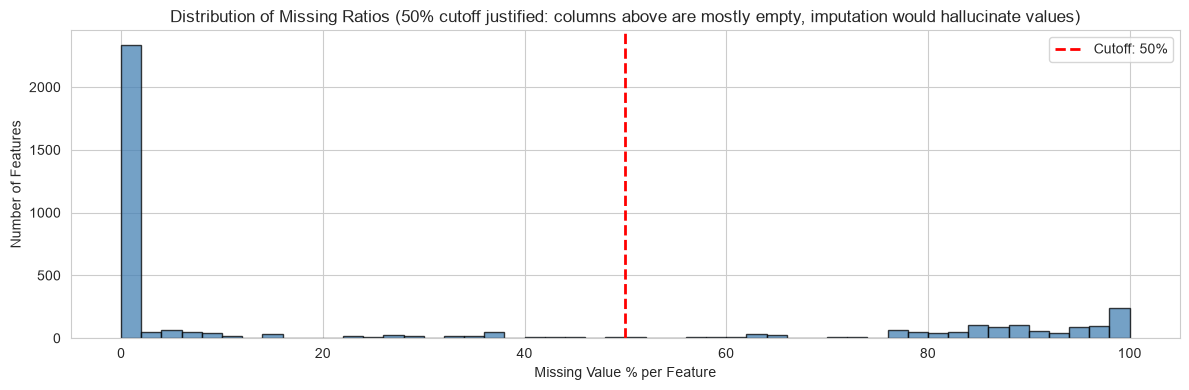

  Missing-ratio plot saved.
  Dropped 1138 columns (>50% missing)

  Cleaning Summary:
  Step                                 Columns
  -------------------------------------------
  Original                               3,923
  After missing drop (>{missing_threshold*100:.0f}%)    2,785  (-1,138)
  After variance threshold ({variance_threshold})    2,012  (-773)
  Final                                  2,012

  Cleaned shape: (9082, 2012)

cleaning_pipeline is unfitted — refit on X_train only in the modeling step.


In [6]:


def clean_dataset(X, y, missing_threshold=0.5, variance_threshold=0.01):
    """
    Data cleaning pipeline.

    Strategy:
    - Column dropping (missing ratio) is data-aware: computed on full X before split,
      because missingness is a structural property of the data, not the split.
    - Imputation and variance thresholding are wrapped in a sklearn Pipeline so they
      can be fitted exclusively on X_train during modeling (avoids leakage).

    Returns:
        X_clean (DataFrame), y (Series), cleaning_pipeline (unfitted Pipeline)
    """
    print("\n" + "="*60)
    print("STEP 1: DATA CLEANING")
    print("="*60)

    n_original = X.shape[1]

    # ── Step 1: Drop columns with too many missing values (data-aware) ─────────
    # Missing ratio is a structural dataset property — safe to compute on all data.
    missing_ratio = X.isnull().mean()

    # Plot missing-ratio distribution with cutoff marker
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(missing_ratio.values * 100, bins=50, color='steelblue',
            edgecolor='black', alpha=0.75)
    ax.axvline(x=missing_threshold * 100, color='red', linestyle='--', linewidth=2,
               label=f'Cutoff: {missing_threshold*100:.0f}%')
    ax.set_xlabel('Missing Value % per Feature')
    ax.set_ylabel('Number of Features')
    ax.set_title('Distribution of Missing Ratios (50% cutoff justified: '
                 'columns above are mostly empty, imputation would hallucinate values)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('missing_ratio_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Missing-ratio plot saved.")

    cols_to_drop = missing_ratio[missing_ratio > missing_threshold].index.tolist()
    X_after_missing = X.drop(columns=cols_to_drop)
    n_after_missing = X_after_missing.shape[1]
    print(f"  Dropped {len(cols_to_drop)} columns (>{missing_threshold*100:.0f}% missing)")

    # ── Step 2: Build Pipeline for imputation + variance filtering ─────────────
    # IMPORTANT: This pipeline is returned UNFITTED.
    # It must be fitted only on X_train to prevent leakage.
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.feature_selection import VarianceThreshold

    cleaning_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('variance_threshold', VarianceThreshold(threshold=variance_threshold)),
    ])

    # For this cleaning step (pre-split EDA/feature selection), we fit on X_after_missing
    # with a clear comment that in the modeling step this must be fit on X_train only.
    import numpy as np
    numeric_cols = X_after_missing.select_dtypes(include=[np.number]).columns.tolist()
    X_numeric = X_after_missing[numeric_cols]

    X_array = cleaning_pipeline.fit_transform(X_numeric)  # EDA fit — NOT modeling fit

    # Recover feature names after variance filter
    vt = cleaning_pipeline.named_steps['variance_threshold']
    kept_cols = X_numeric.columns[vt.get_support()].tolist()
    X_clean = pd.DataFrame(X_array, columns=kept_cols, index=X_numeric.index)

    n_after_variance = X_clean.shape[1]

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\n  Cleaning Summary:")
    print(f"  {'Step':<35} {'Columns':>8}")
    print(f"  {'-'*43}")
    print(f"  {'Original':35} {n_original:>8,}")
    print(f"  {'After missing drop (>{missing_threshold*100:.0f}%)':35} {n_after_missing:>8,}  (-{n_original - n_after_missing:,})")
    print(f"  {'After variance threshold ({variance_threshold})':35} {n_after_variance:>8,}  (-{n_after_missing - n_after_variance:,})")
    print(f"  {'Final':35} {n_after_variance:>8,}")
    print(f"\n  Cleaned shape: {X_clean.shape}")

    # cleaning_pipeline returned for use in modeling (fit on X_train only there)
    return X_clean, y, cleaning_pipeline


X_clean, y_clean, cleaning_pipeline = clean_dataset(X, y)
print("\ncleaning_pipeline is unfitted — refit on X_train only in the modeling step.")


### EDA


STEP 2: EXPLORATORY DATA ANALYSIS


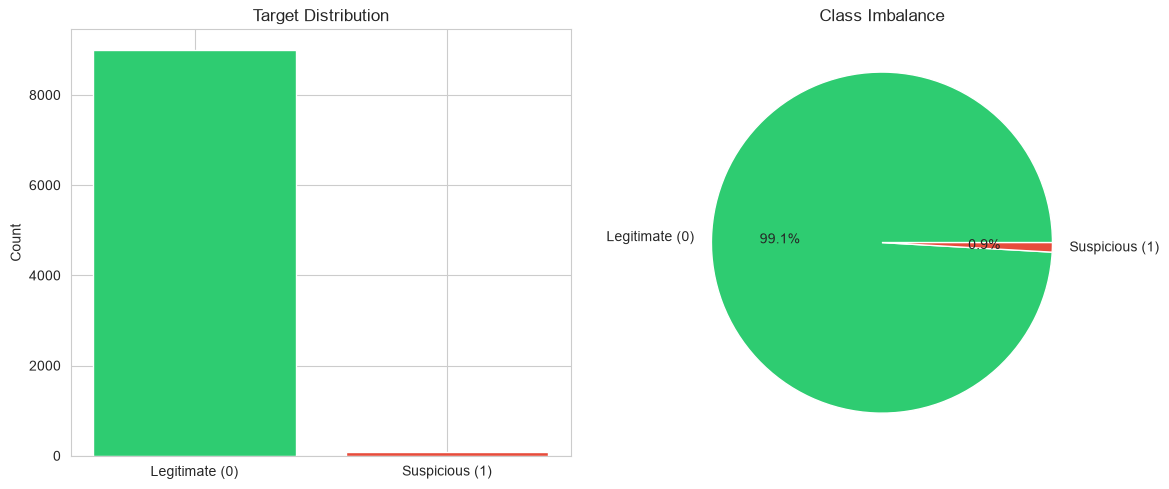


  Analyzing class separability with PCA...


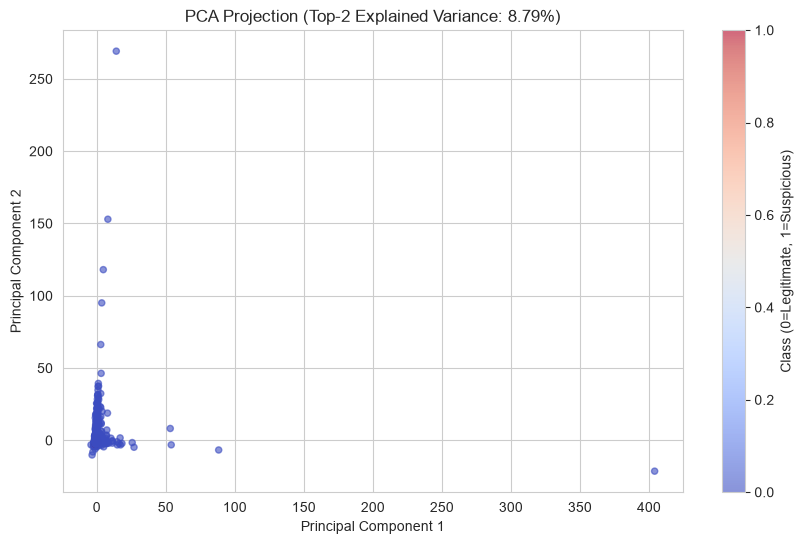

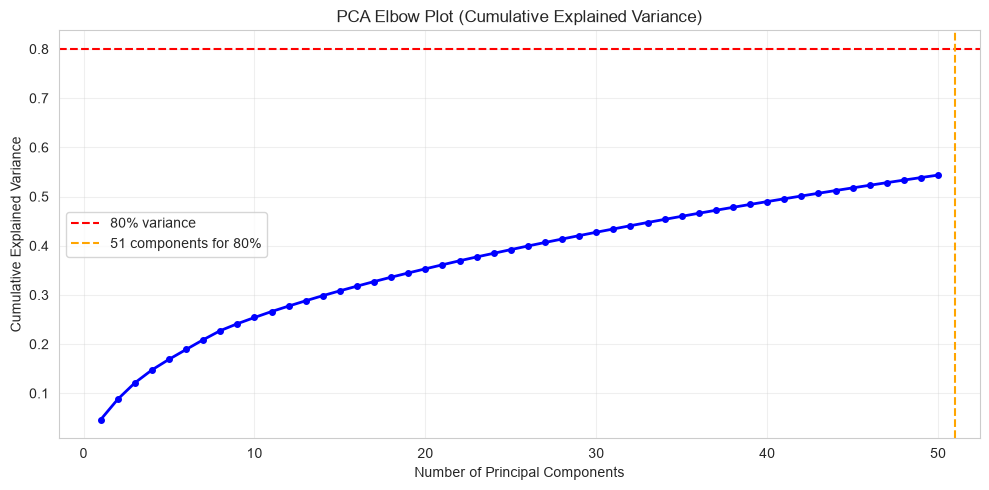

  Components needed to reach 80% variance: 51 / 50

  Running UMAP for non-linear visualization...


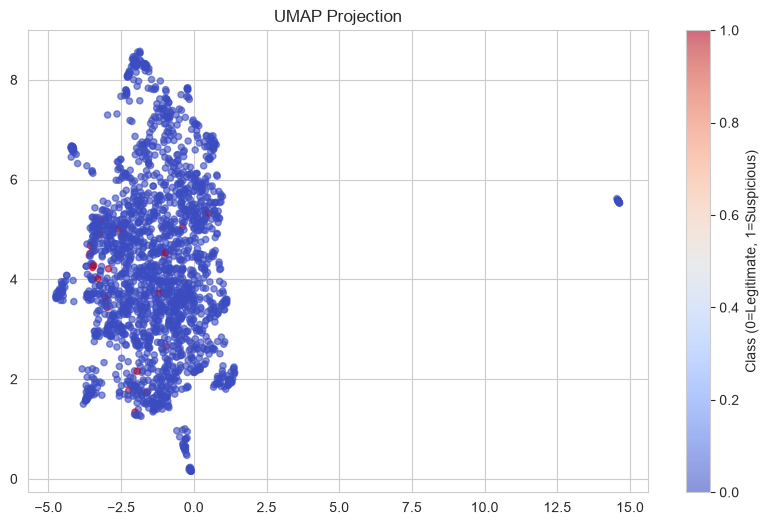


  Ranking features by Mann-Whitney U p-value (most discriminative first)...
  Top 6 most discriminative features (by Mann-Whitney U p-value):
    F3811                 p = 3.06e-24
    F3805                 p = 7.99e-24
    F3799                 p = 5.86e-23
    F1813                 p = 9.57e-23
    F1921                 p = 2.92e-22
    F1705                 p = 4.04e-22


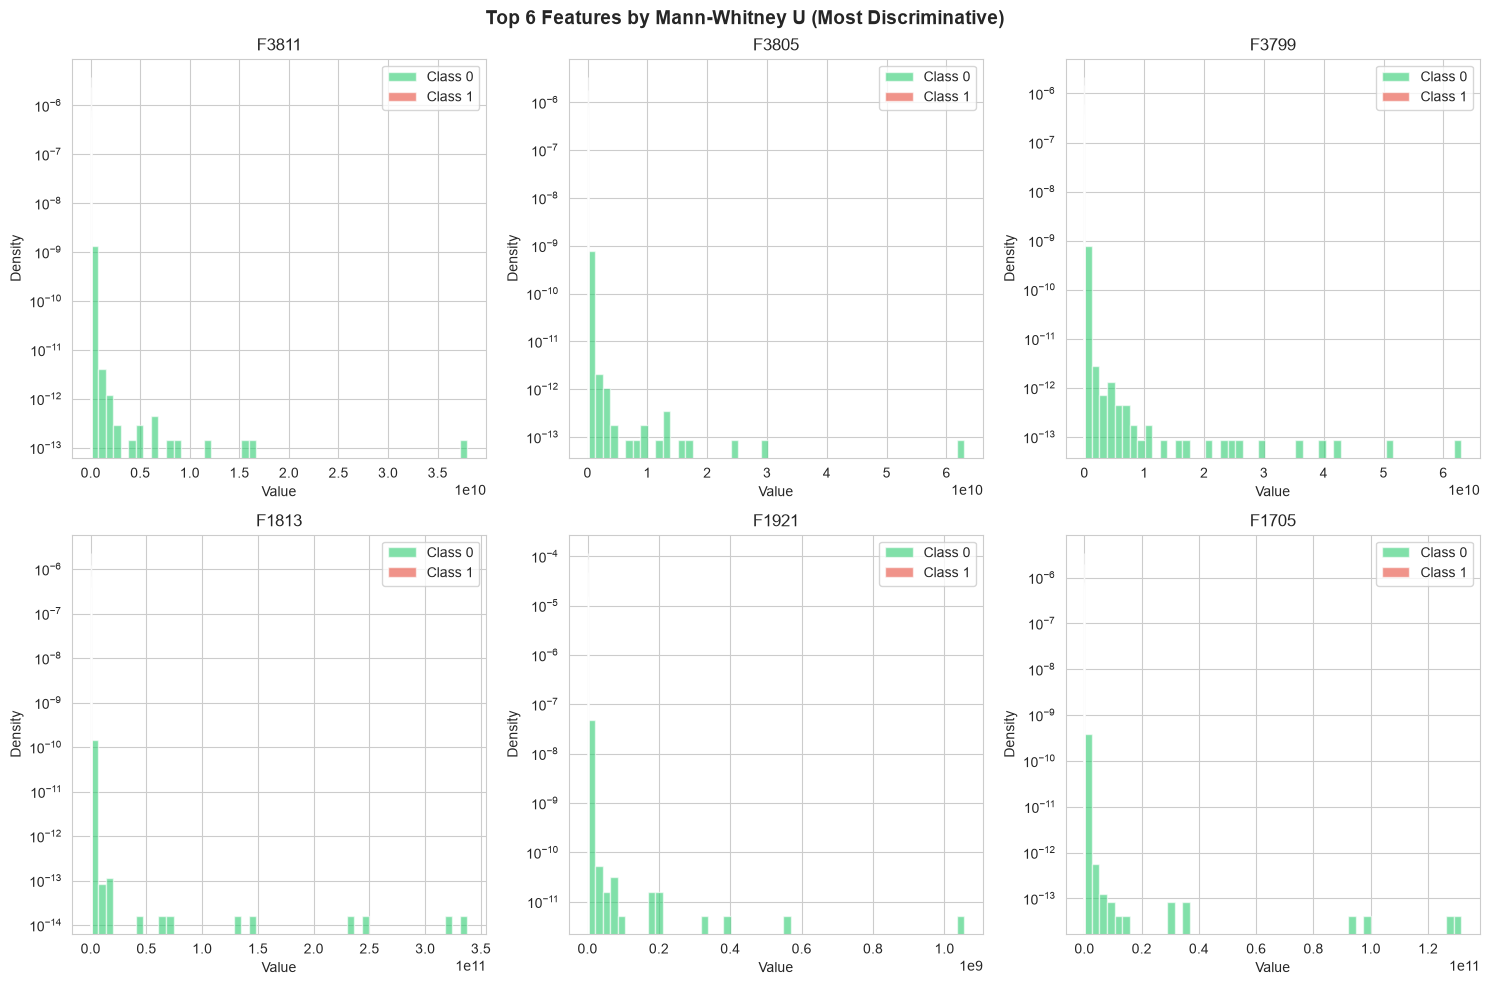


  EDA complete


In [7]:


def perform_eda(X, y, max_samples=2000):
    """
    Comprehensive EDA. Top features selected by Mann-Whitney U p-value
    (most discriminative between classes), not by variance.
    PCA includes elbow plot and low-variance warning.
    StandardScaler here is visualization-only -- NOT the modeling scaler.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import mannwhitneyu
    from sklearn.preprocessing import StandardScaler  # visualization-only
    from sklearn.decomposition import PCA
    import umap

    print("\n" + "="*60)
    print("STEP 2: EXPLORATORY DATA ANALYSIS")
    print("="*60)

    # ── 1. Target Distribution ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(
        ['Legitimate (0)', 'Suspicious (1)'],
        y.value_counts().sort_index(),
        color=['#2ecc71', '#e74c3c']
    )
    axes[0].set_title('Target Distribution')
    axes[0].set_ylabel('Count')

    axes[1].pie(
        y.value_counts().sort_index(),
        labels=['Legitimate (0)', 'Suspicious (1)'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c']
    )
    axes[1].set_title('Class Imbalance')

    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 2. PCA for Class Separability ──────────────────────────────────────────
    print("\n  Analyzing class separability with PCA...")
    sample_size = min(max_samples, len(X))
    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y.loc[X_sample.index]

    # NOTE: This scaler is for visualization only -- NOT used in modeling.
    vis_scaler = StandardScaler()
    X_scaled = vis_scaler.fit_transform(X_sample)

    # 2a. 2-component PCA scatter
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(X_scaled)
    top2_var = pca2.explained_variance_ratio_.sum()

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        X_pca2[:, 0], X_pca2[:, 1],
        c=y_sample, cmap='coolwarm', alpha=0.6, s=20
    )
    plt.colorbar(scatter, label='Class (0=Legitimate, 1=Suspicious)')
    plt.title(f'PCA Projection (Top-2 Explained Variance: {top2_var:.2%})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Warning if PCA scatter is not interpretable
    if top2_var < 0.05:
        print("  WARNING: Top 2 PCs explain <5% variance -- "
              "PCA scatter is not interpretable. "
              "Consider using UMAP or t-SNE instead.")

    # 2b. PCA elbow plot -- cumulative explained variance up to 50 components
    n_elbow = min(50, X_scaled.shape[1], X_scaled.shape[0] - 1)
    pca_elbow = PCA(n_components=n_elbow)
    pca_elbow.fit(X_scaled)
    cumvar = np.cumsum(pca_elbow.explained_variance_ratio_)

    # Find how many components reach 80%
    n_80pct = int(np.searchsorted(cumvar, 0.80)) + 1

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, n_elbow + 1), cumvar, 'bo-', linewidth=2, markersize=4)
    ax.axhline(y=0.80, color='red', linestyle='--', label='80% variance')
    ax.axvline(x=n_80pct, color='orange', linestyle='--',
               label=f'{n_80pct} components for 80%')
    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title('PCA Elbow Plot (Cumulative Explained Variance)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pca_elbow.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Components needed to reach 80% variance: {n_80pct} / {n_elbow}")

    # ── 3. UMAP (if manageable) ────────────────────────────────────────────────
    if len(X) < 10000:
        print("\n  Running UMAP for non-linear visualization...")
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
        X_umap = reducer.fit_transform(X_scaled)

        plt.figure(figsize=(10, 6))
        plt.scatter(X_umap[:, 0], X_umap[:, 1],
                    c=y_sample, cmap='coolwarm', alpha=0.6, s=20)
        plt.colorbar(label='Class (0=Legitimate, 1=Suspicious)')
        plt.title('UMAP Projection')
        plt.savefig('umap_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()

    # ── 4. Top Features by Mann-Whitney U p-value ──────────────────────────────
    # Mann-Whitney U tests whether the two class distributions differ significantly.
    # Low p-value = feature is discriminative between classes (not just high variance).
    print("\n  Ranking features by Mann-Whitney U p-value (most discriminative first)...")

    mw_results = []
    for feat in X.columns:
        class0 = X[y == 0][feat].dropna()
        class1 = X[y == 1][feat].dropna()
        if len(class0) > 1 and len(class1) > 1:
            _, pval = mannwhitneyu(class0, class1, alternative='two-sided')
            mw_results.append((feat, pval))

    mw_results.sort(key=lambda x: x[1])  # ascending p-value = most discriminative first
    top_features = [f for f, _ in mw_results[:6]]

    print(f"  Top 6 most discriminative features (by Mann-Whitney U p-value):")
    for feat, pval in mw_results[:6]:
        print(f"    {feat:<20}  p = {pval:.2e}")

    # Plot distributions for top discriminative features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        for class_val, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
            subset = X[y == class_val][feat].dropna()
            axes[i].hist(subset, bins=50, alpha=0.6,
                         color=color, label=f'Class {class_val}', density=True)
        axes[i].set_title(f'{feat}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
        axes[i].legend()
        axes[i].set_yscale('log')

    plt.suptitle('Top 6 Features by Mann-Whitney U (Most Discriminative)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n  EDA complete")
    return mw_results  # return for potential downstream reuse


mw_ranking = perform_eda(X_clean, y_clean)



### 6. STATISTICAL FEATURE SELECTION



STEP 3: STATISTICAL FEATURE SELECTION

  Stage 1: Computing Mutual Information scores...


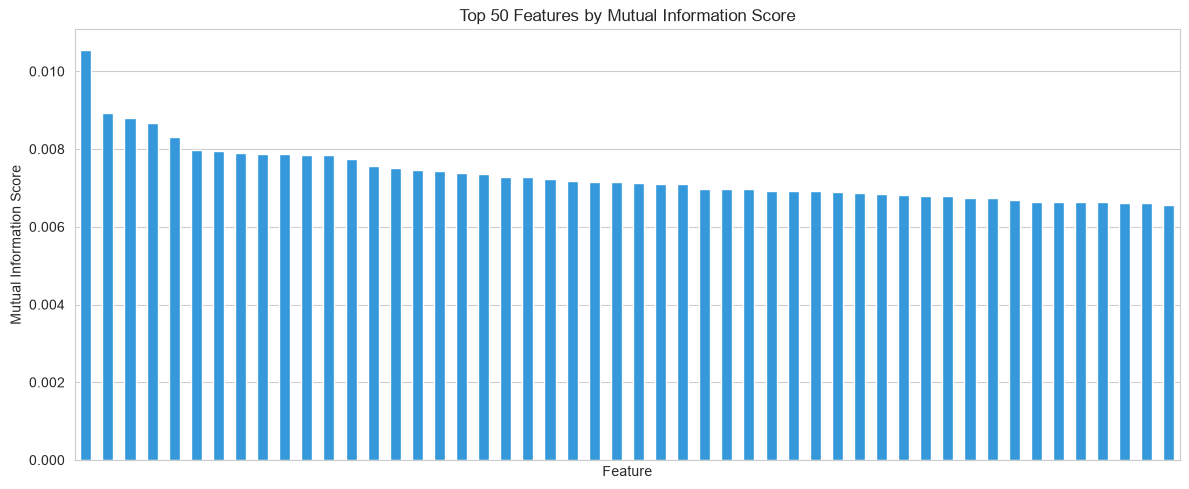

  MI score range: [0.0000, 0.0105]
  Selected 150 candidate features

  Stage 2: PR-AUC vs k elbow plot (k = 20, 50, 100, 200)...
    k=  20  PR-AUC = 0.5813 (+/-0.2533)
    k=  50  PR-AUC = 0.6063 (+/-0.2841)
    k= 100  PR-AUC = 0.7585 (+/-0.1410)


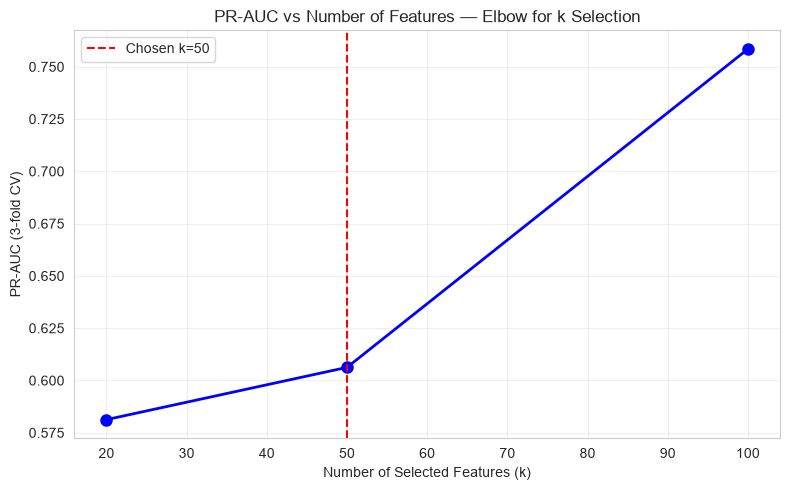


  Stage 3: Random Forest importance (class_weight='balanced')...


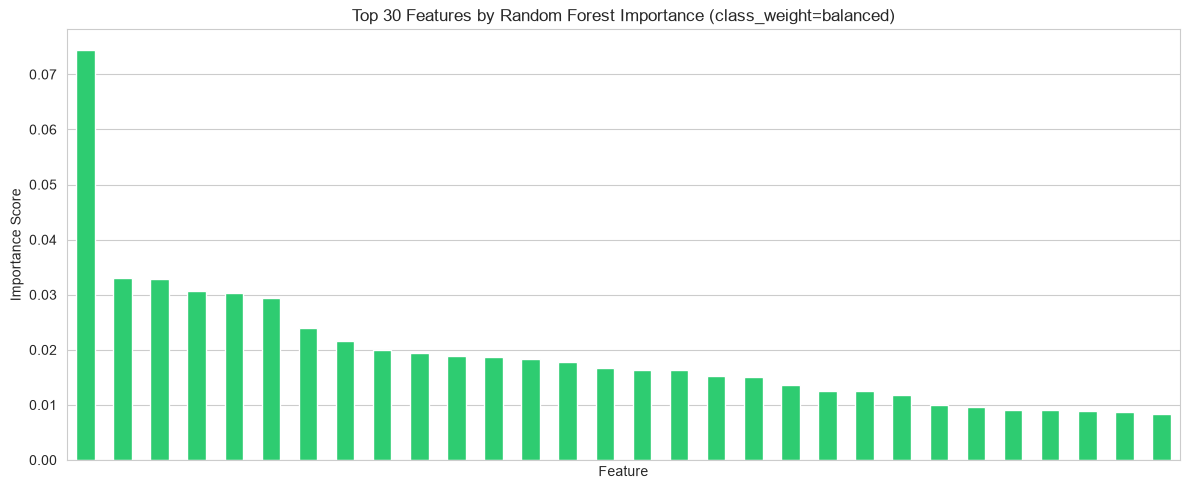

  Selected features saved to: selected_features.csv

  Final selected: 50 features
  Top 10 features: ['F3898', 'F1813', 'F3805', 'F3799', 'F3806', 'F3811', 'F3807', 'F1815', 'F3801', 'F1825']


In [8]:


def select_features_statistically(X, y, n_final_features=50, mi_scores_cache=None):
    """
    Data-driven feature selection using Mutual Information and Random Forest.

    Parameters
    ----------
    mi_scores_cache : pd.Series or None
        Pre-computed MI scores (index = feature names, values = MI scores).
        If provided, MI computation is skipped (saves ~2–5 min on large datasets).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.model_selection import StratifiedKFold, cross_val_score

    print("\n" + "="*60)
    print("STEP 3: STATISTICAL FEATURE SELECTION")
    print("="*60)

    # ── Stage 1: Mutual Information (cached if available) ─────────────────────
    if mi_scores_cache is not None:
        print("\n  Stage 1: Using cached MI scores (skipping recomputation).")
        mi_series = mi_scores_cache.sort_values(ascending=False)
    else:
        print("\n  Stage 1: Computing Mutual Information scores...")
        mi_raw = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
        mi_series = pd.Series(mi_raw, index=X.columns).sort_values(ascending=False)

    # Visualize MI scores
    plt.figure(figsize=(12, 5))
    mi_series.head(50).plot(kind='bar', color='#3498db')
    plt.title('Top 50 Features by Mutual Information Score')
    plt.xlabel('Feature')
    plt.ylabel('Mutual Information Score')
    plt.xticks([])
    plt.tight_layout()
    plt.savefig('mutual_information_scores.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  MI score range: [{mi_series.min():.4f}, {mi_series.max():.4f}]")

    # Select top candidates (3x final desired)
    candidate_features = mi_series.head(n_final_features * 3).index.tolist()
    X_candidates = X[candidate_features]
    print(f"  Selected {len(candidate_features)} candidate features")

    # ── Stage 2: PR-AUC vs k elbow plot ───────────────────────────────────────
    # Use a light XGBoost with 3-fold CV to justify n_final_features choice.
    # Pick k at the elbow (diminishing returns in PR-AUC).
    print("\n  Stage 2: PR-AUC vs k elbow plot (k = 20, 50, 100, 200)...")

    k_values = [k for k in [20, 50, 100, 200] if k <= len(candidate_features)]
    prauc_scores = []
    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for k in k_values:
        X_k = X_candidates[mi_series.head(k).index.tolist()]
        xgb_light = XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            objective='binary:logistic', eval_metric='aucpr',
            random_state=42, n_jobs=-1, verbosity=0
        )
        scores = cross_val_score(
            xgb_light, X_k, y,
            cv=cv3, scoring='average_precision', n_jobs=-1
        )
        prauc_scores.append(scores.mean())
        print(f"    k={k:4d}  PR-AUC = {scores.mean():.4f} (+/-{scores.std()*2:.4f})")

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, prauc_scores, 'bo-', linewidth=2, markersize=8)
    plt.axvline(x=n_final_features, color='red', linestyle='--',
                label=f'Chosen k={n_final_features}')
    plt.xlabel('Number of Selected Features (k)')
    plt.ylabel('PR-AUC (3-fold CV)')
    plt.title('PR-AUC vs Number of Features — Elbow for k Selection')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('prauc_vs_k.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Stage 3: Random Forest with class_weight='balanced' ───────────────────
    print("\n  Stage 3: Random Forest importance (class_weight='balanced')...")
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # handles minority class properly
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_candidates, y)

    rf_importance = pd.Series(
        rf.feature_importances_,
        index=candidate_features
    ).sort_values(ascending=False)

    plt.figure(figsize=(12, 5))
    rf_importance.head(30).plot(kind='bar', color='#2ecc71')
    plt.title('Top 30 Features by Random Forest Importance (class_weight=balanced)')
    plt.xlabel('Feature')
    plt.ylabel('Importance Score')
    plt.xticks([])
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Final features
    final_features = rf_importance.head(n_final_features).index.tolist()
    X_selected = X[final_features]

    # ── Save selected features to CSV for reproducibility ─────────────────────
    import os
    feat_df = pd.DataFrame({
        'feature': final_features,
        'rf_importance': rf_importance[final_features].values,
        'mi_score': mi_series[final_features].values
    })
    feat_df.to_csv('selected_features.csv', index=False)
    print(f"  Selected features saved to: selected_features.csv")

    print(f"\n  Final selected: {len(final_features)} features")
    print(f"  Top 10 features: {final_features[:10]}")

    return X_selected, final_features, mi_series, rf_importance


X_selected, selected_features, mi_scores_cached, rf_importance = \
    select_features_statistically(X_clean, y_clean)


In [9]:

print("\n" + "="*60)
print("STEP 4: DATA PREPARATION")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Split data — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_clean,
    test_size=0.25,
    random_state=42,
    stratify=y_clean
)

print("\nTrain-Test Split:")
print(f"  Training  : {len(X_train):,} samples")
print(f"  Testing   : {len(X_test):,}  samples")

# Class distribution
train_class0 = int((y_train == 0).sum())
train_class1 = int((y_train == 1).sum())
test_class0  = int((y_test  == 0).sum())
test_class1  = int((y_test  == 1).sum())

print("\nClass Distribution:")
print(f"  Train — Class 0: {train_class0:,} ({train_class0/len(y_train)*100:.2f}%)")
print(f"  Train — Class 1: {train_class1:,} ({train_class1/len(y_train)*100:.2f}%)")
print(f"  Test  — Class 0: {test_class0:,}  ({test_class0/len(y_test)*100:.2f}%)")
print(f"  Test  — Class 1: {test_class1:,}  ({test_class1/len(y_test)*100:.2f}%)")

# scale_pos_weight for XGBoost (XGBoost's class_weight='balanced' equivalent)
scale_pos_weight = train_class0 / train_class1 if train_class1 > 0 else 1.0
print(f"\nscale_pos_weight (XGBoost imbalance param): {scale_pos_weight:.2f}")

# ── Tree model inputs (raw DataFrames, no scaling) ────────────────────────────
# X_train and X_test keep column names — required for SHAP feature attribution.
# The cleaning_pipeline returned from clean_dataset() should be used here
# to impute X_train/X_test (fit on X_train only to prevent leakage).

# Re-fit the cleaning pipeline on X_train only
cleaning_pipeline.fit(X_train)
vt_step = cleaning_pipeline.named_steps['variance_threshold']
train_kept_cols = X_train.columns[vt_step.get_support()].tolist()

import numpy as np
X_train_imp = pd.DataFrame(
    cleaning_pipeline.transform(X_train),
    columns=train_kept_cols,
    index=X_train.index
)
# For test: transform only (no fit)
X_test_imp = pd.DataFrame(
    cleaning_pipeline.transform(X_test),
    columns=train_kept_cols,
    index=X_test.index
)

print(f"\nTree model inputs (after imputation, no scaling):")
print(f"  X_train_imp : {X_train_imp.shape}")
print(f"  X_test_imp  : {X_test_imp.shape}")

# ── Scaler available for LR baseline only ─────────────────────────────────────
lr_scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    lr_scaler.fit_transform(X_train_imp),
    columns=train_kept_cols,
    index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    lr_scaler.transform(X_test_imp),
    columns=train_kept_cols,
    index=X_test_imp.index
)
print(f"  X_train_scaled (LR only): {X_train_scaled.shape}")

selected_feature_names = list(X_train_imp.columns)
print(f"\nFinal feature count : {len(selected_feature_names):,}")
print(f"Top 5 features      : {selected_feature_names[:5]}")
print("\nData Preparation Complete.")



STEP 4: DATA PREPARATION

Train-Test Split:
  Training  : 6,811 samples
  Testing   : 2,271  samples

Class Distribution:
  Train — Class 0: 6,750 (99.10%)
  Train — Class 1: 61 (0.90%)
  Test  — Class 0: 2,251  (99.12%)
  Test  — Class 1: 20  (0.88%)

scale_pos_weight (XGBoost imbalance param): 110.66

Tree model inputs (after imputation, no scaling):
  X_train_imp : (6811, 50)
  X_test_imp  : (2271, 50)
  X_train_scaled (LR only): (6811, 50)

Final feature count : 50
Top 5 features      : ['F3898', 'F1813', 'F3805', 'F3799', 'F3806']

Data Preparation Complete.


### 8. MODEL TRAINING & EVALUATION

In [10]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np


def find_optimal_threshold(model, X_val, y_val):
    """
    Find the decision threshold that maximises F1-score on a validation set.
    Iterates thresholds from 0.10 to 0.90 in steps of 0.01.
    Uses the held-out validation fold ONLY -- not the test set.
    """
    y_proba_val = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_f1, best_thr = 0.0, 0.50
    for thr in thresholds:
        y_pred_thr = (y_proba_val >= thr).astype(int)
        f1 = f1_score(y_val, y_pred_thr, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return round(best_thr, 2), round(best_f1, 4)


def train_and_evaluate_models(X_train, X_test, y_train, y_test,
                               X_train_scaled, X_test_scaled,
                               scale_pos_weight):
    """
    Train and compare XGBoost, LightGBM, CatBoost, and Logistic Regression.

    Imbalance strategy (unified rationale):
    - XGBoost    : scale_pos_weight = n_neg / n_pos  (XGBoost's equivalent of balanced)
    - LightGBM   : class_weight='balanced'            (replaces is_unbalance=True)
    - CatBoost   : auto_class_weights='Balanced'      (CatBoost's native equivalent)
    - LogReg     : class_weight='balanced'            (standard sklearn)

    Threshold: NOT hard-coded. Found per model by maximising F1 on a held-out
    validation fold (20% of train), independent of the test set.
    """
    print("\n" + "="*70)
    print("STEP 5: MODEL TRAINING & EVALUATION")
    print("="*70)

    # Hold out a validation fold for threshold tuning (not used in final scoring)
    from sklearn.model_selection import train_test_split as tts
    X_tr, X_val, y_tr, y_val = tts(
        X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
    )
    X_tr_sc, X_val_sc, _, _ = tts(
        X_train_scaled, y_train, test_size=0.20, random_state=42, stratify=y_train
    )

    # ── Model definitions ─────────────────────────────────────────────────────
    # All use class-imbalance handling appropriate for each library.
    # Hyper-params are kept consistent across models for fair comparison.

    models = {
        'XGBoost': {
            'model': XGBClassifier(
                n_estimators=500, max_depth=5, learning_rate=0.03,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,  # = n_neg/n_pos (balanced equiv)
                min_child_weight=5, gamma=1,
                reg_alpha=0.5, reg_lambda=2,
                objective='binary:logistic', eval_metric='aucpr',
                random_state=42, n_jobs=-1, verbosity=0
            ),
            'X_train': X_tr, 'X_val': X_val, 'X_test': X_test, 'scaled': False
        },
        'LightGBM': {
            'model': LGBMClassifier(
                n_estimators=500, learning_rate=0.03, num_leaves=31,
                feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                reg_alpha=0.5, reg_lambda=2,
                class_weight='balanced',   # unified strategy (replaces is_unbalance)
                objective='binary', random_state=42, verbose=-1, n_jobs=-1
            ),
            'X_train': X_tr, 'X_val': X_val, 'X_test': X_test, 'scaled': False
        },
        'CatBoost': {
            'model': CatBoostClassifier(
                iterations=500, depth=6, learning_rate=0.03,
                auto_class_weights='Balanced',  # CatBoost balanced equivalent
                loss_function='Logloss', random_seed=42, verbose=0
            ),
            'X_train': X_tr, 'X_val': X_val, 'X_test': X_test, 'scaled': False
        },
        'LogisticRegression': {
            # Baseline: uses scaled inputs (tree models don't need scaling).
            # Separate StandardScaler fitted on X_train_scaled (already done in Cell 4).
            'model': LogisticRegression(
                class_weight='balanced', max_iter=1000, C=1.0,
                random_state=42, n_jobs=-1
            ),
            'X_train': X_tr_sc, 'X_val': X_val_sc,
            'X_test': X_test_scaled, 'scaled': True
        },
    }

    results = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, cfg in models.items():
        model    = cfg['model']
        Xt       = cfg['X_train']
        Xv       = cfg['X_val']
        Xte      = cfg['X_test']
        yt       = y_tr
        yv       = y_val

        print(f"\n{'='*50}")
        print(f"Training {name}")
        print(f"{'='*50}")

        # Cross-validation on full X_train (before val split) for fair CV estimate
        cv_scores = cross_val_score(
            model, X_train if not cfg['scaled'] else X_train_scaled,
            y_train, cv=cv, scoring='average_precision', n_jobs=-1
        )
        print(f"CV PR-AUC (5-fold): {cv_scores.mean():.4f} (+/-{cv_scores.std()*2:.4f})")

        # Fit on train portion (excluding val) for threshold tuning
        model.fit(Xt, yt)

        # Find optimal threshold on validation fold
        opt_thr, val_f1 = find_optimal_threshold(model, Xv, yv)
        print(f"Optimal threshold  : {opt_thr} (val F1 = {val_f1:.4f})")

        # Evaluate on TEST set with the optimal threshold
        y_proba = model.predict_proba(Xte)[:, 1]
        y_pred  = (y_proba >= opt_thr).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall    = recall_score(y_test, y_pred, zero_division=0)
        f1        = f1_score(y_test, y_pred, zero_division=0)
        auc_roc   = roc_auc_score(y_test, y_proba)
        pr_auc    = average_precision_score(y_test, y_proba)

        results[name] = {
            'model': model,
            'precision': precision, 'recall': recall, 'f1': f1,
            'auc_roc': auc_roc, 'pr_auc': pr_auc,
            'cv_pr_auc': cv_scores.mean(),
            'optimal_threshold': opt_thr
        }

        print(f"\nTest Metrics (threshold={opt_thr}):")
        print(f"  Precision : {precision:.4f}")
        print(f"  Recall    : {recall:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        print(f"  PR-AUC    : {pr_auc:.4f}")
        print(f"  ROC-AUC   : {auc_roc:.4f}")

        cm = confusion_matrix(y_test, y_pred)
        print(f"\n  Confusion Matrix:")
        print(f"  TN={cm[0,0]:5d} | FP={cm[0,1]:5d}")
        print(f"  FN={cm[1,0]:5d} | TP={cm[1,1]:5d}")

    # ── Comparison table ───────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MODEL COMPARISON")
    print("="*70)

    comparison_df = pd.DataFrame(results).T[
        ['recall', 'precision', 'f1', 'pr_auc', 'auc_roc',
         'cv_pr_auc', 'optimal_threshold']
    ].sort_values('pr_auc', ascending=False)

    print(comparison_df.round(4).to_string())

    best_model_name = comparison_df.index[0]
    best_model = results[best_model_name]['model']

    print(f"\nBEST MODEL: {best_model_name}")
    print(f"  PR-AUC            : {comparison_df.loc[best_model_name,'pr_auc']:.4f}")
    print(f"  Recall            : {comparison_df.loc[best_model_name,'recall']:.4f}")
    print(f"  Optimal Threshold : {comparison_df.loc[best_model_name,'optimal_threshold']}")

    return results, best_model, best_model_name, comparison_df


In [11]:
# ============================================================
# Run model training & evaluation
# ============================================================
results, best_model, best_model_name, comparison_df = train_and_evaluate_models(
    X_train=X_train_imp,
    X_test=X_test_imp,
    y_train=y_train,
    y_test=y_test,
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    scale_pos_weight=scale_pos_weight
)



STEP 5: MODEL TRAINING & EVALUATION

Training XGBoost
CV PR-AUC (5-fold): 0.7849 (+/-0.1791)
Optimal threshold  : 0.43 (val F1 = 0.8800)

Test Metrics (threshold=0.43):
  Precision : 0.6000
  Recall    : 0.6000
  F1-Score  : 0.6000
  PR-AUC    : 0.7265
  ROC-AUC   : 0.9942

  Confusion Matrix:
  TN= 2243 | FP=    8
  FN=    8 | TP=   12

Training LightGBM
CV PR-AUC (5-fold): 0.7652 (+/-0.1827)
Optimal threshold  : 0.74 (val F1 = 0.9091)

Test Metrics (threshold=0.74):
  Precision : 0.7500
  Recall    : 0.6000
  F1-Score  : 0.6667
  PR-AUC    : 0.7020
  ROC-AUC   : 0.9908

  Confusion Matrix:
  TN= 2247 | FP=    4
  FN=    8 | TP=   12

Training CatBoost
CV PR-AUC (5-fold): 0.7858 (+/-0.1350)
Optimal threshold  : 0.59 (val F1 = 0.8800)

Test Metrics (threshold=0.59):
  Precision : 0.7222
  Recall    : 0.6500
  F1-Score  : 0.6842
  PR-AUC    : 0.7556
  ROC-AUC   : 0.9951

  Confusion Matrix:
  TN= 2246 | FP=    5
  FN=    7 | TP=   13

Training LogisticRegression
CV PR-AUC (5-fold): 0.2

# VISUALIZN

In [12]:


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import umap
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['axes.labelsize'] = 12


VISUALIZATION 1: DATASET OVERVIEW


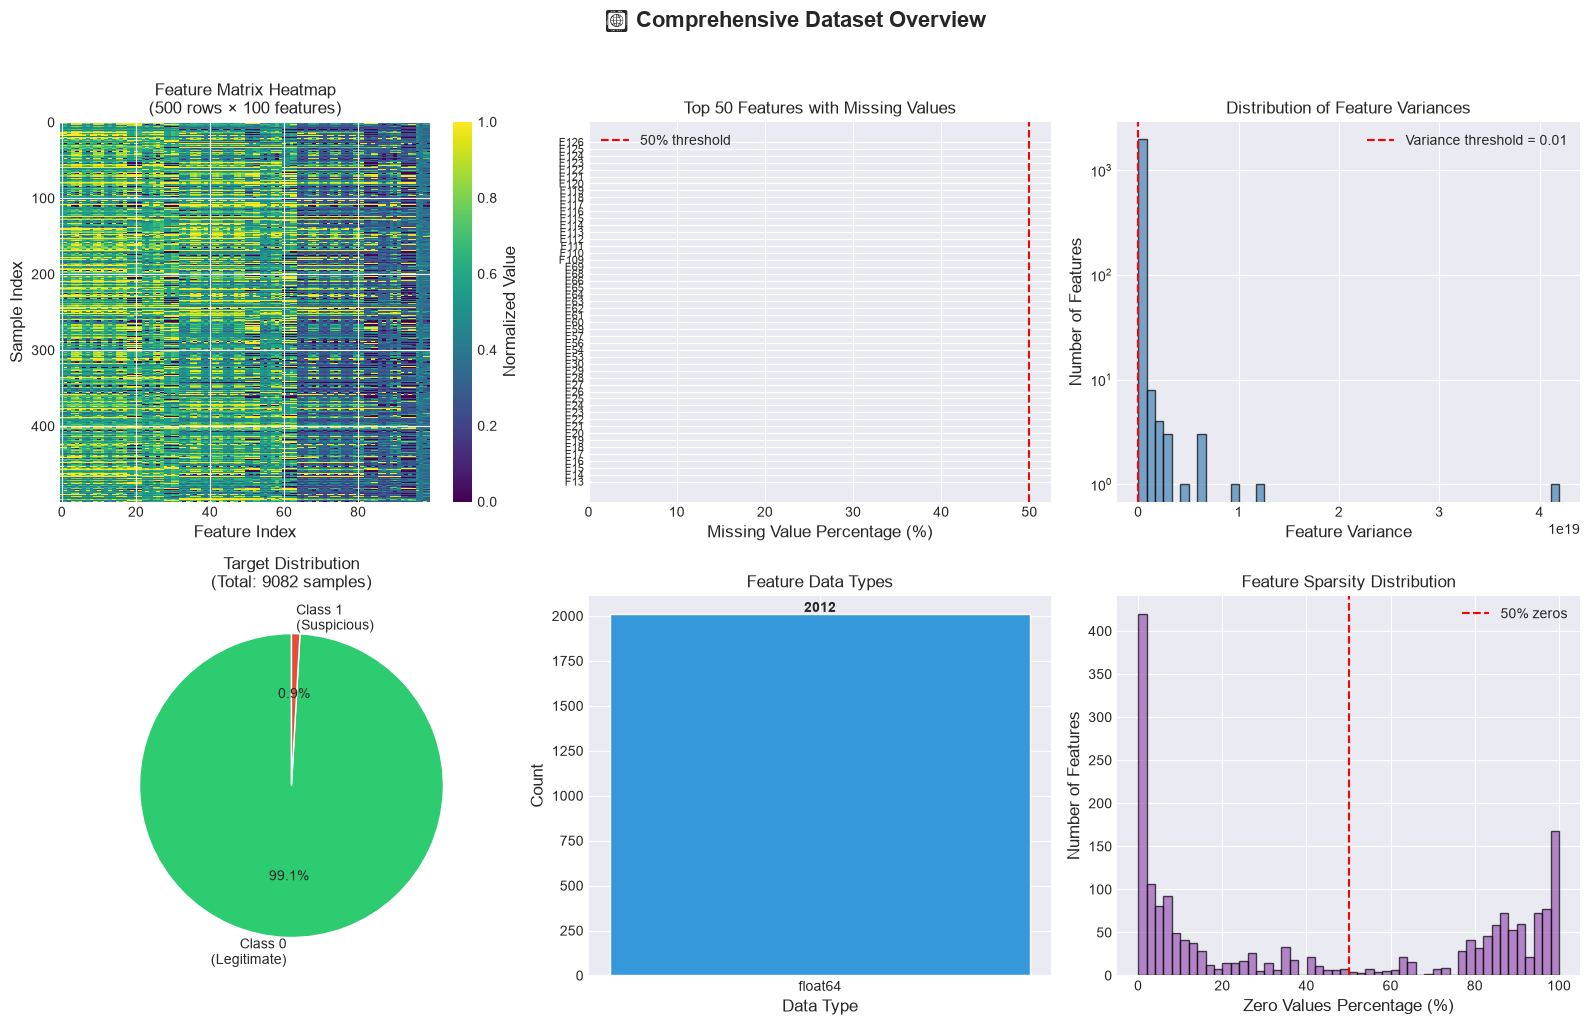


✅ Key Insights:
   • Total samples: 9,082
   • Total features: 2,012
   • Features with >50% missing: 0
   • Features with zero variance: 0
   • Class imbalance ratio: 111.1:1


In [13]:
# VISUALIZATION 1: HIGH-LEVEL DATASET OVERVIEW


def visualize_dataset_overview(X, y):
    """
    Overall dataset statistics and structure
    """
    print("\n" + "="*80)
    print("VISUALIZATION 1: DATASET OVERVIEW")
    print("="*80)
    
    fig = plt.figure(figsize=(16, 10))
    
    # 1. Feature matrix heatmap (sampled)
    ax1 = plt.subplot(2, 3, 1)
    sample_size = min(500, X.shape[0])
    sample_features = min(100, X.shape[1])
    
    # Take a sample for visualization
    X_sample = X.iloc[:sample_size, :sample_features]
    
    # Normalize for better visualization
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_normalized = scaler.fit_transform(X_sample)
    
    im = ax1.imshow(X_normalized, aspect='auto', cmap='viridis', interpolation='nearest')
    ax1.set_title(f'Feature Matrix Heatmap\n({sample_size} rows × {sample_features} features)')
    ax1.set_xlabel('Feature Index')
    ax1.set_ylabel('Sample Index')
    plt.colorbar(im, ax=ax1, label='Normalized Value')
    
    # 2. Missing values pattern
    ax2 = plt.subplot(2, 3, 2)
    missing_percent = (X.isnull().sum() / len(X)) * 100
    missing_percent_sorted = missing_percent.sort_values(ascending=False)
    top_missing = missing_percent_sorted.head(50)
    
    ax2.barh(range(len(top_missing)), top_missing.values, color='coral')
    ax2.set_yticks(range(len(top_missing)))
    ax2.set_yticklabels(top_missing.index, fontsize=8)
    ax2.set_xlabel('Missing Value Percentage (%)')
    ax2.set_title('Top 50 Features with Missing Values')
    ax2.axvline(x=50, color='red', linestyle='--', label='50% threshold')
    ax2.legend()
    
    # 3. Feature variance distribution
    ax3 = plt.subplot(2, 3, 3)
    feature_vars = X.var()
    ax3.hist(feature_vars, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Feature Variance')
    ax3.set_ylabel('Number of Features')
    ax3.set_title('Distribution of Feature Variances')
    ax3.set_yscale('log')
    ax3.axvline(x=0.01, color='red', linestyle='--', label='Variance threshold = 0.01')
    ax3.legend()
    
    # 4. Class distribution
    ax4 = plt.subplot(2, 3, 4)
    class_counts = y.value_counts()
    colors = ['#2ecc71', '#e74c3c']
    wedges, texts, autotexts = ax4.pie(class_counts, labels=['Class 0\n(Legitimate)', 'Class 1\n(Suspicious)'],
                                        autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title(f'Target Distribution\n(Total: {len(y)} samples)')
    
    # 5. Data type distribution
    ax5 = plt.subplot(2, 3, 5)
    dtype_counts = X.dtypes.value_counts()
    ax5.bar(dtype_counts.index.astype(str), dtype_counts.values, color='#3498db')
    ax5.set_xlabel('Data Type')
    ax5.set_ylabel('Count')
    ax5.set_title('Feature Data Types')
    for i, (dtype, count) in enumerate(dtype_counts.items()):
        ax5.text(i, count + 10, str(count), ha='center', fontweight='bold')
    
    # 6. Feature sparsity
    ax6 = plt.subplot(2, 3, 6)
    zero_percent = (X == 0).mean() * 100
    sparsity_dist = zero_percent[zero_percent > 0]
    ax6.hist(sparsity_dist, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
    ax6.set_xlabel('Zero Values Percentage (%)')
    ax6.set_ylabel('Number of Features')
    ax6.set_title('Feature Sparsity Distribution')
    ax6.axvline(x=50, color='red', linestyle='--', label='50% zeros')
    ax6.legend()
    
    plt.suptitle('📊 Comprehensive Dataset Overview', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('01_dataset_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Key Insights:")
    print(f"   • Total samples: {len(X):,}")
    print(f"   • Total features: {X.shape[1]:,}")
    print(f"   • Features with >50% missing: {(missing_percent > 50).sum():,}")
    print(f"   • Features with zero variance: {(feature_vars == 0).sum():,}")
    print(f"   • Class imbalance ratio: {len(y[y==0])/len(y[y==1]):.1f}:1")

# Run visualization
visualize_dataset_overview(X_clean, y_clean)

### VISUALIZATION 2: DIMENSIONALITY REDUCTION


VISUALIZATION 2: CLASS SEPARABILITY ANALYSIS
  Computing UMAP...


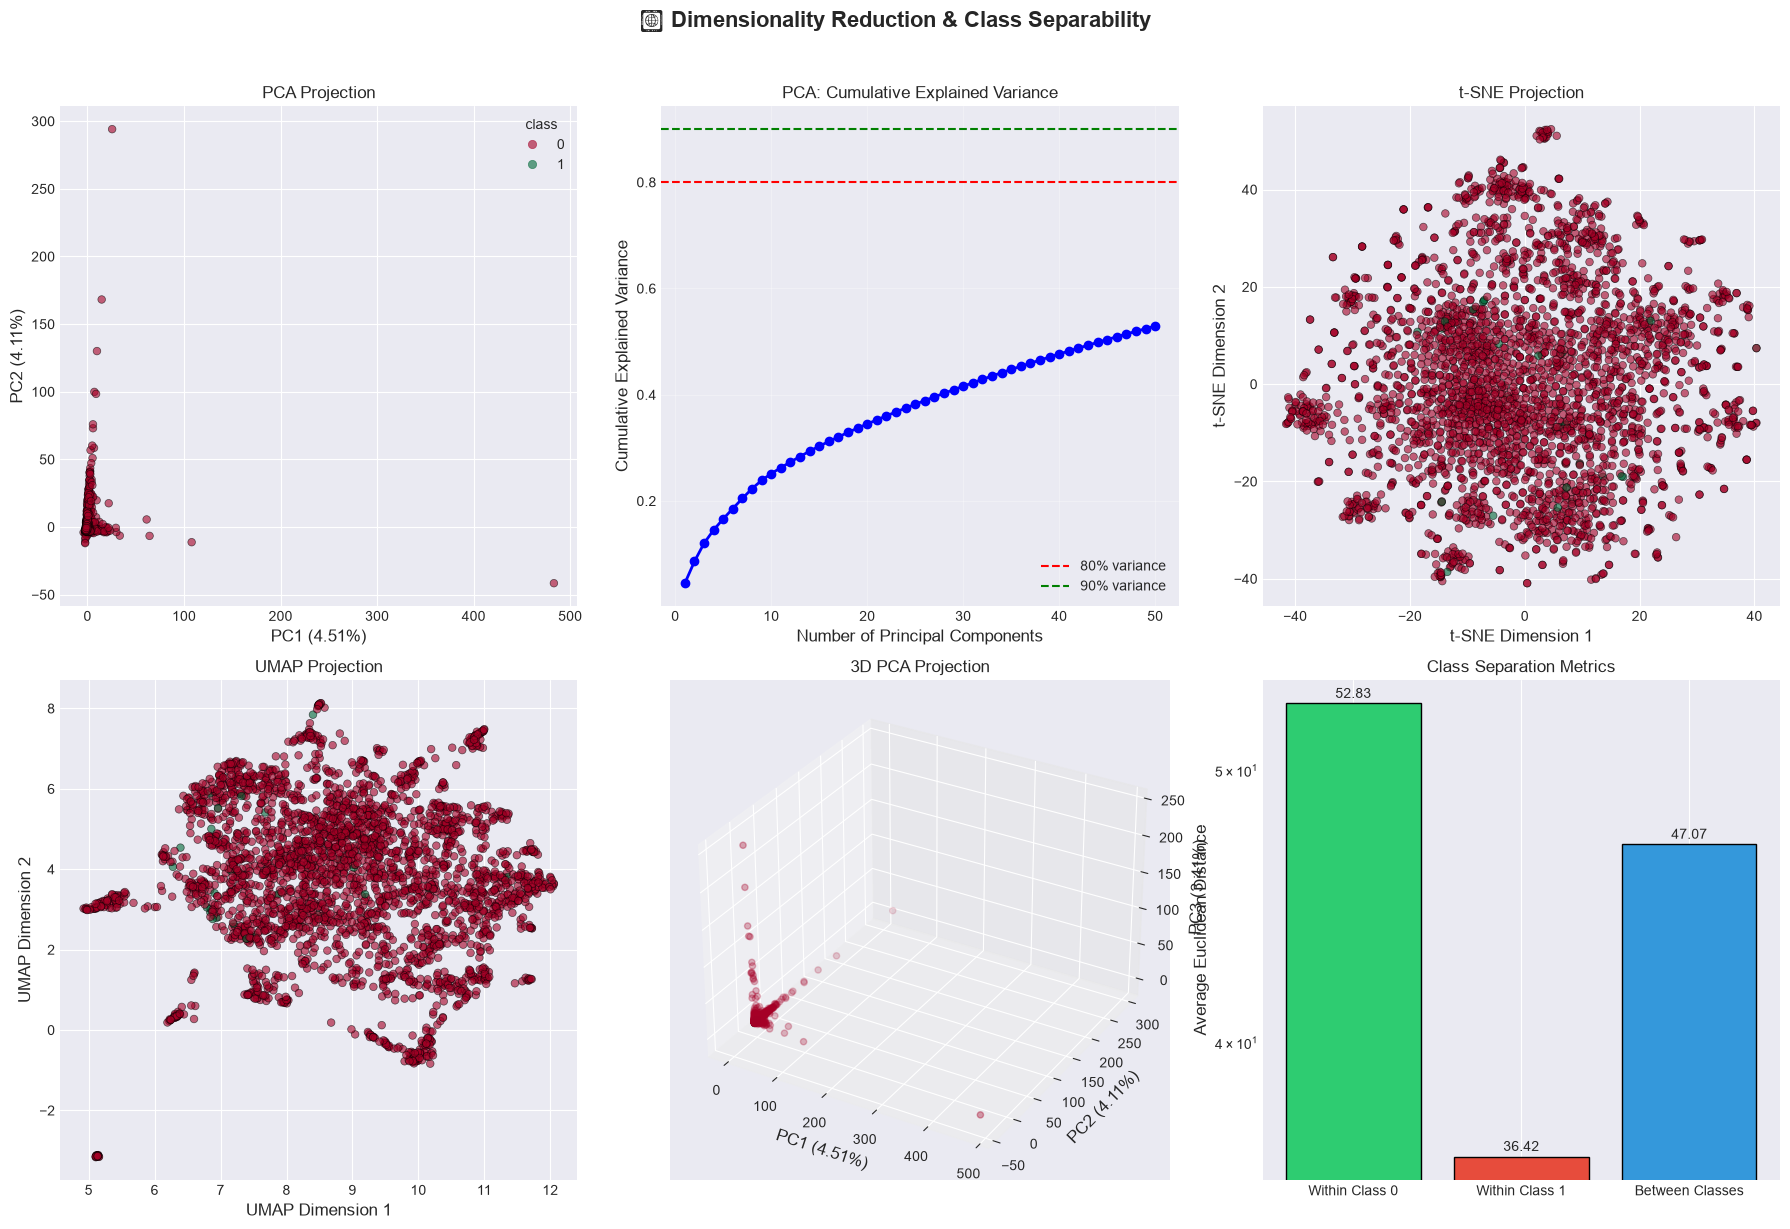


✅ Class Separability Insights:
   • PCA explained variance (first 2 components): 8.61%
   • t-SNE and UMAP show local structure preservation
   • Between-class distance vs within-class: 1.05x


In [14]:


def visualize_dimensionality_reduction(X, y):

    print("\n" + "="*80)
    print("VISUALIZATION 2: CLASS SEPARABILITY ANALYSIS")
    print("="*80)
    
    # Sample for faster computation
    sample_size = min(3000, len(X))
    np.random.seed(42)
    sample_indices = np.random.choice(len(X), sample_size, replace=False)
    X_sample = X.iloc[sample_indices]
    y_sample = y.iloc[sample_indices]
    
    # Standardize
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    
    fig = plt.figure(figsize=(18, 12))
    
    # 1. PCA (Principal Component Analysis)
    ax1 = plt.subplot(2, 3, 1)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='RdYlGn', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax1.set_title('PCA Projection')
    handles, labels = scatter1.legend_elements()
    ax1.legend(handles,labels,title = 'class')


    
    # 2. Explained variance ratio
    ax2 = plt.subplot(2, 3, 2)
    pca_full = PCA(n_components=50)
    pca_full.fit(X_scaled)
    cumsum_ratio = np.cumsum(pca_full.explained_variance_ratio_)
    
    ax2.plot(range(1, 51), cumsum_ratio, 'bo-', linewidth=2, markersize=6)
    ax2.axhline(y=0.8, color='r', linestyle='--', label='80% variance')
    ax2.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
    ax2.set_xlabel('Number of Principal Components')
    ax2.set_ylabel('Cumulative Explained Variance')
    ax2.set_title('PCA: Cumulative Explained Variance')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)
    ax3 = plt.subplot(2, 3, 3)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    
    scatter3 = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='RdYlGn',
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    ax3.set_xlabel('t-SNE Dimension 1')
    ax3.set_ylabel('t-SNE Dimension 2')
    ax3.set_title('t-SNE Projection')
    
    # 4. UMAP (Uniform Manifold Approximation)
    ax4 = plt.subplot(2, 3, 4)
    print("  Computing UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_scaled)
    
    scatter4 = ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='RdYlGn',
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    ax4.set_xlabel('UMAP Dimension 1')
    ax4.set_ylabel('UMAP Dimension 2')
    ax4.set_title('UMAP Projection')
    
    # 5. 3D PCA
    ax5 = plt.subplot(2, 3, 5, projection='3d')
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)
    
    scatter5 = ax5.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                           c=y_sample, cmap='RdYlGn', alpha=0.6, s=20)
    ax5.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
    ax5.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
    ax5.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
    ax5.set_title('3D PCA Projection')
    
    # 6. Class separation metrics
    ax6 = plt.subplot(2, 3, 6)
    
    # Calculate between-class vs within-class distance ratio
    from sklearn.metrics.pairwise import euclidean_distances
    
    X_class0 = X_scaled[y_sample == 0]
    X_class1 = X_scaled[y_sample == 1]
    
    if len(X_class0) > 0 and len(X_class1) > 0:
        # Calculate distances
        within_class0 = np.mean(euclidean_distances(X_class0[:min(100, len(X_class0))]))
        within_class1 = np.mean(euclidean_distances(X_class1[:min(100, len(X_class1))]))
        between_class = np.mean(euclidean_distances(X_class0[:min(100, len(X_class0))], 
                                                     X_class1[:min(100, len(X_class1))]))
        
        metrics = ['Within Class 0', 'Within Class 1', 'Between Classes']
        values = [within_class0, within_class1, between_class]
        colors_metrics = ['#2ecc71', '#e74c3c', '#3498db']
        
        bars = ax6.bar(metrics, values, color=colors_metrics, edgecolor='black')
        ax6.set_ylabel('Average Euclidean Distance')
        ax6.set_title('Class Separation Metrics')
        ax6.set_yscale('log')
        
        # Add value labels
        for bar, val in zip(bars, values):
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.2f}', ha='center', va='bottom')
    
    plt.suptitle('🎯 Dimensionality Reduction & Class Separability', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('02_dimensionality_reduction.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Class Separability Insights:")
    print(f"   • PCA explained variance (first 2 components): {pca.explained_variance_ratio_.sum():.2%}")
    print(f"   • t-SNE and UMAP show local structure preservation")
    if len(X_class0) > 0 and len(X_class1) > 0:
        print(f"   • Between-class distance vs within-class: {between_class/((within_class0+within_class1)/2):.2f}x")

# Run dimensionality reduction visualization
visualize_dimensionality_reduction(X_clean, y_clean)


VISUALIZATION 3: FEATURE BEHAVIOR ANALYSIS


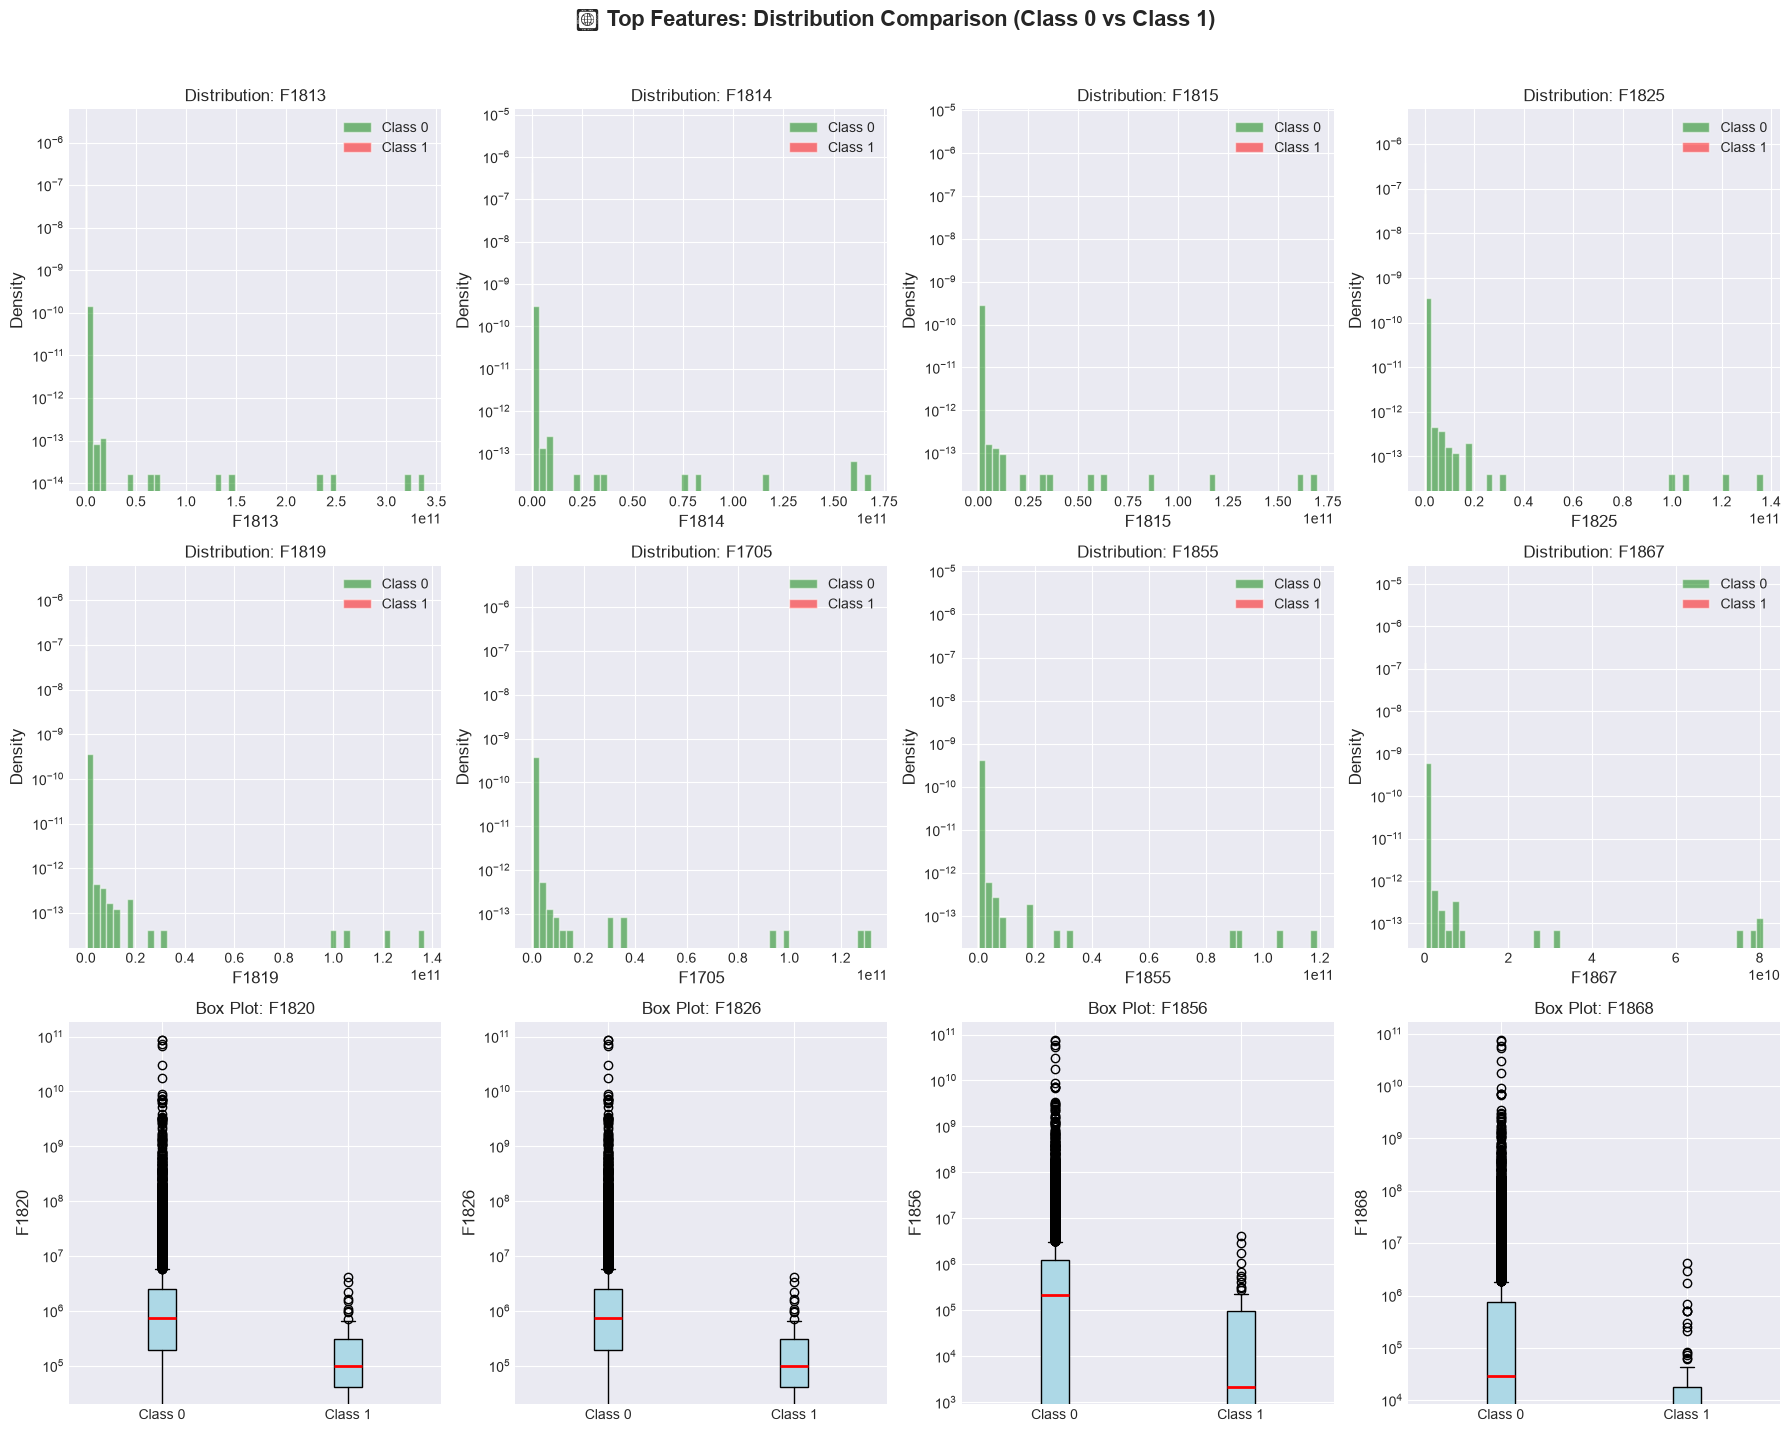


  Performing statistical tests (Mann-Whitney U)...


KeyboardInterrupt: 

In [15]:


def visualize_feature_behavior(X, y):
    """
    Analyze how features behave across classes
    """
    print("\n" + "="*80)
    print("VISUALIZATION 3: FEATURE BEHAVIOR ANALYSIS")
    print("="*80)
    
    # Select top features by variance
    feature_vars = X.var().sort_values(ascending=False)
    top_features = feature_vars.head(12).index.tolist()
    
    fig = plt.figure(figsize=(18, 14))
    
    # 1. Distribution comparison for top features
    for i, feature in enumerate(top_features[:8]):
        ax = plt.subplot(3, 4, i+1)
        
        for class_val, color, label in [(0, 'green', 'Class 0'), (1, 'red', 'Class 1')]:
            data = X[y == class_val][feature].dropna()
            if len(data) > 0:
                ax.hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
        
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.set_title(f'Distribution: {feature}')
        ax.legend()
        ax.set_yscale('log')
    
    # 2. Box plots for top features
    for i, feature in enumerate(top_features[8:12]):
        ax = plt.subplot(3, 4, i+9)
        
        data_to_plot = [X[y == 0][feature].dropna(), X[y == 1][feature].dropna()]
        bp = ax.boxplot(data_to_plot,tick_labels=['Class 0', 'Class 1'],patch_artist=True,boxprops=dict(facecolor='lightblue'),medianprops=dict(color='red', linewidth=2))
        ax.set_ylabel(feature)
        ax.set_title(f'Box Plot: {feature}')
        ax.set_yscale('log')
    
    plt.suptitle('📈 Top Features: Distribution Comparison (Class 0 vs Class 1)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('03_feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Statistical test for feature differences
    print("\n  Performing statistical tests (Mann-Whitney U)...")
    from scipy.stats import mannwhitneyu
    
    significant_features = []
    for feature in X.columns:
        class0 = X[y == 0][feature].dropna()
        class1 = X[y == 1][feature].dropna()
        
        if len(class0) > 0 and len(class1) > 0:
            stat, p_value = mannwhitneyu(class0, class1, alternative='two-sided')
            if p_value < 0.05:
                significant_features.append((feature, p_value))
    
    significant_features.sort(key=lambda x: x[1])
    
    print(f"  ✅ Found {len(significant_features)} statistically significant features (p < 0.05)")
    print("\n  Top 10 most discriminative features:")
    for feat, p_val in significant_features[:10]:
        print(f"    • {feat}: p-value = {p_val:.6f}")

# Run feature behavior analysis
visualize_feature_behavior(X_clean, y_clean)

### VISUALIZATION 4: CORRELATION STRUCTURE


VISUALIZATION 4: CORRELATION STRUCTURE
  Computing feature-target correlations...


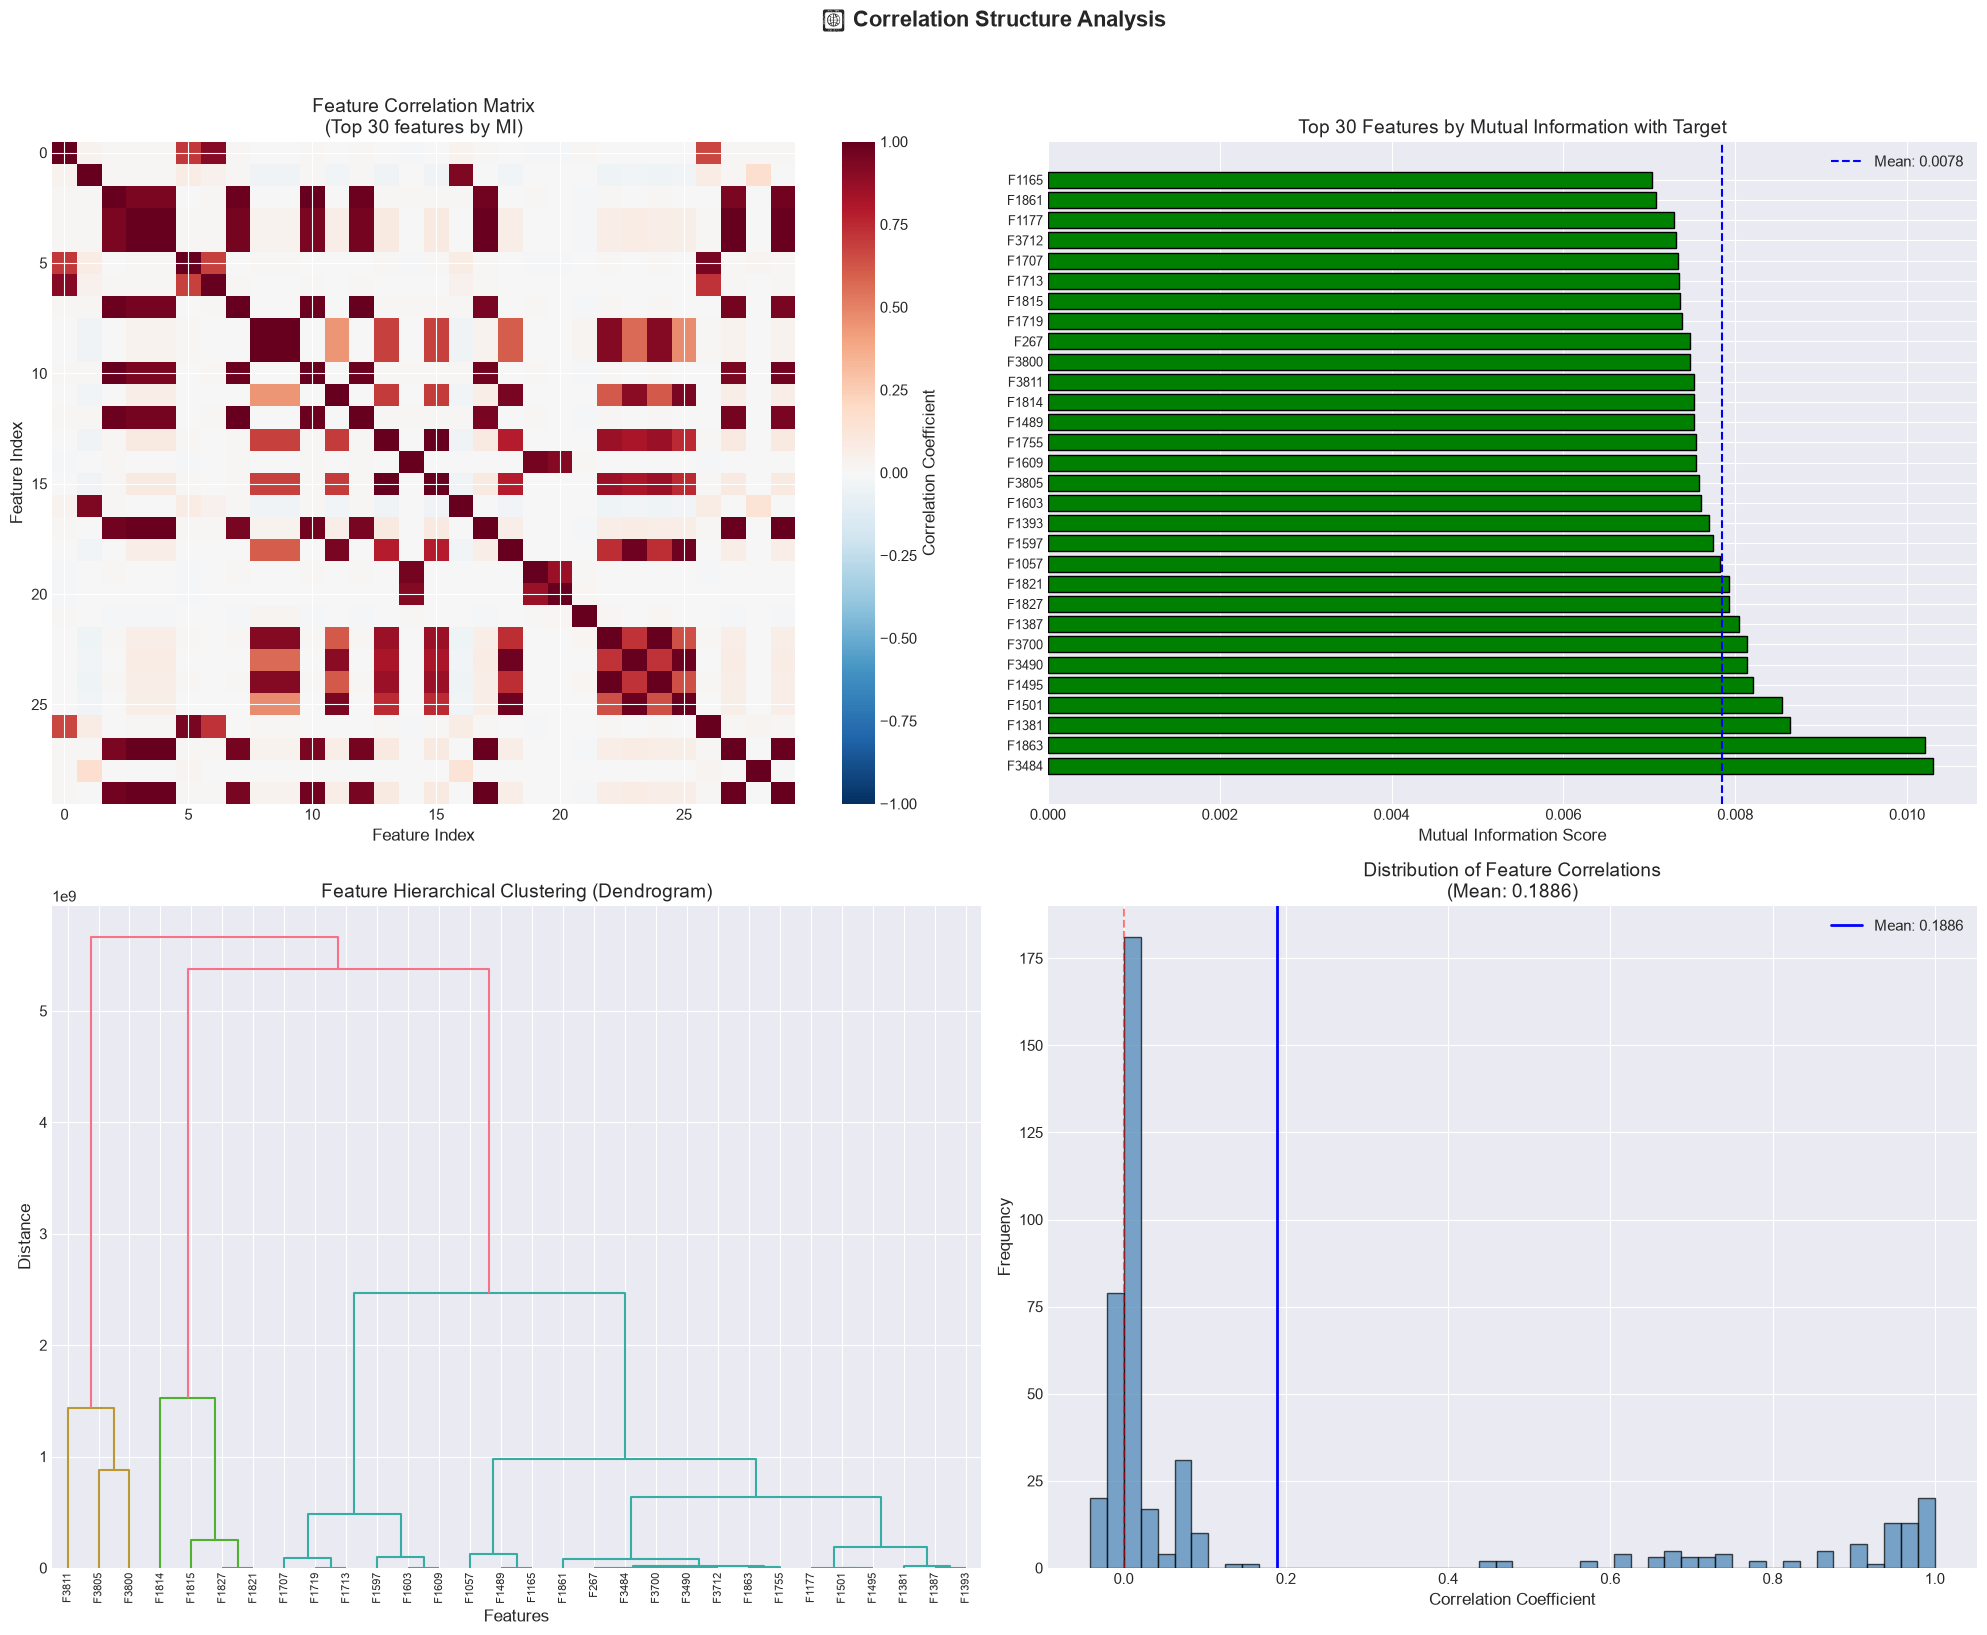


✅ Correlation Insights:
   • Average feature-feature correlation: 0.1886
   • Features with high correlation (>0.7): 71 pairs
   • Top MI score: 0.0103 for feature F3484


In [ ]:


def visualize_correlation_structure(X, y):
    """
    Visualize correlations between features and with target
    """
    print("\n" + "="*80)
    print("VISUALIZATION 4: CORRELATION STRUCTURE")
    print("="*80)
    
    # Select top features for correlation analysis
    # Use Mutual Information to select most relevant features
    from sklearn.feature_selection import mutual_info_classif
    
    print("  Computing feature-target correlations...")
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_corr_features = mi_series.head(30).index.tolist()
    
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Correlation heatmap
    ax1 = plt.subplot(2, 2, 1)
    X_top = X[top_corr_features]
    corr_matrix = X_top.corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    im = ax1.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax1.set_title(f'Feature Correlation Matrix\n(Top {len(top_corr_features)} features by MI)')
    ax1.set_xlabel('Feature Index')
    ax1.set_ylabel('Feature Index')
    plt.colorbar(im, ax=ax1, label='Correlation Coefficient')
    
    # 2. Correlation with target
    ax2 = plt.subplot(2, 2, 2)
    target_corr = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_30 = target_corr.head(30)
    
    colors_plt = ['green' if x > 0 else 'red' for x in top_30.values]
    ax2.barh(range(len(top_30)), top_30.values, color=colors_plt, edgecolor='black')
    ax2.set_yticks(range(len(top_30)))
    ax2.set_yticklabels(top_30.index, fontsize=9)
    ax2.set_xlabel('Mutual Information Score')
    ax2.set_title('Top 30 Features by Mutual Information with Target')
    ax2.axvline(x=top_30.mean(), color='blue', linestyle='--', label=f'Mean: {top_30.mean():.4f}')
    ax2.legend()
    
    # 3. Feature clusters (dendrogram)
    from scipy.cluster.hierarchy import dendrogram, linkage
    
    ax3 = plt.subplot(2, 2, 3)
    X_sample = X[top_corr_features].sample(min(500, len(X)), random_state=42)
    linkage_matrix = linkage(X_sample.T, method='ward')
    
    dendrogram(linkage_matrix, labels=top_corr_features, ax=ax3, leaf_rotation=90, leaf_font_size=8)
    ax3.set_title('Feature Hierarchical Clustering (Dendrogram)')
    ax3.set_xlabel('Features')
    ax3.set_ylabel('Distance')
    
    # 4. Correlation distribution
    ax4 = plt.subplot(2, 2, 4)
    # Get upper triangle of correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    corr_values = upper_tri.values.flatten()
    corr_values = corr_values[~np.isnan(corr_values)]
    
    ax4.hist(corr_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax4.set_xlabel('Correlation Coefficient')
    ax4.set_ylabel('Frequency')
    ax4.set_title(f'Distribution of Feature Correlations\n(Mean: {np.mean(corr_values):.4f})')
    ax4.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax4.axvline(x=np.mean(corr_values), color='blue', linestyle='-', linewidth=2, label=f'Mean: {np.mean(corr_values):.4f}')
    ax4.legend()
    
    plt.suptitle('🔗 Correlation Structure Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('04_correlation_structure.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Correlation Insights:")
    print(f"   • Average feature-feature correlation: {np.mean(corr_values):.4f}")
    print(f"   • Features with high correlation (>0.7): {sum(corr_values > 0.7)} pairs")
    print(f"   • Top MI score: {top_30.iloc[0]:.4f} for feature {top_30.index[0]}")

# Run correlation visualization
visualize_correlation_structure(X_clean, y_clean)

### VISUALIZATION 5: OUTLIER & ANOMALY DETECTION



VISUALIZATION 5: OUTLIER & ANOMALY DETECTION
  Scaling features...
  Applying PCA (100 components)...
  Running Isolation Forest...


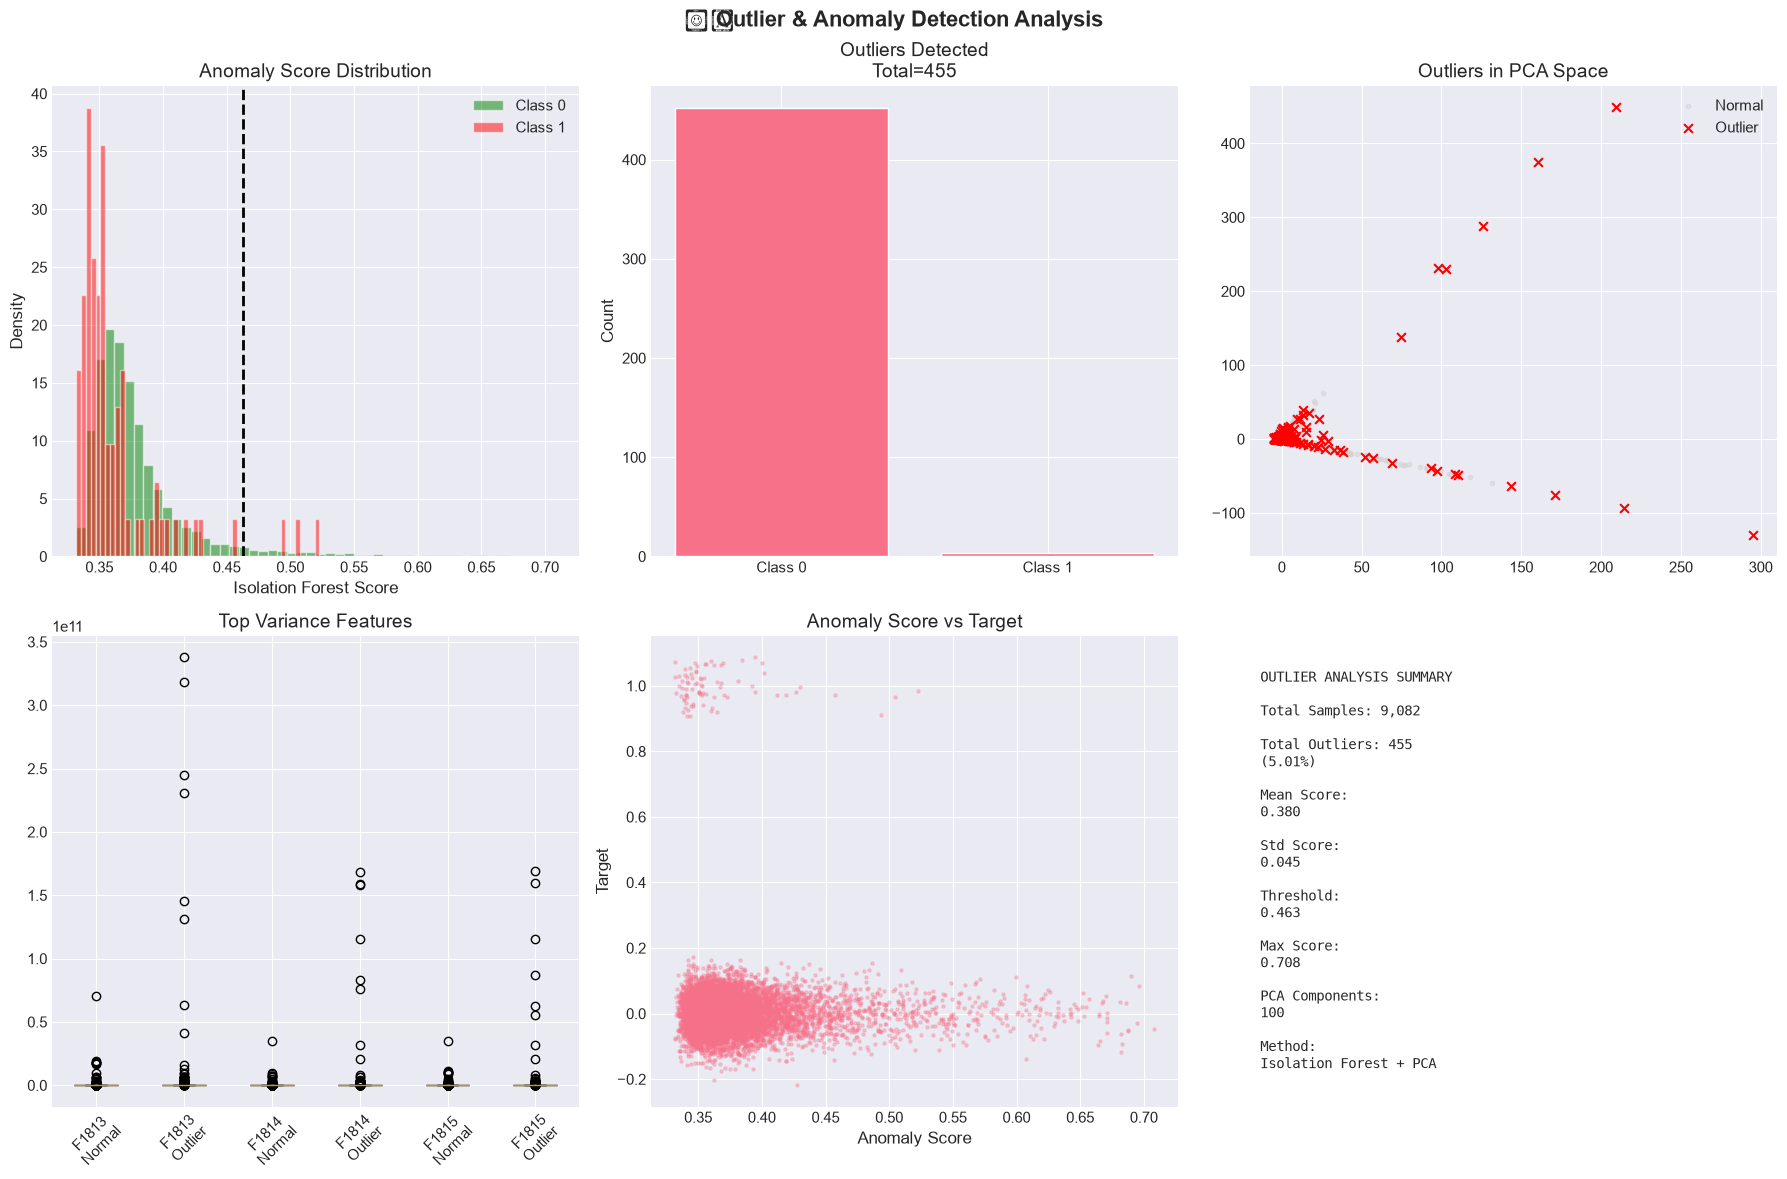


✅ Outlier Analysis Insights:
   • Total outliers detected: 455 (5.01%)
   • Mean anomaly score: 0.380
   • Maximum anomaly score: 0.708


In [ ]:
def visualize_outliers_anomalies(X, y):

    print("\n" + "="*80)
    print("VISUALIZATION 5: OUTLIER & ANOMALY DETECTION")
    print("="*80)

    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.ensemble import IsolationForest

    # ==========================================================
    # Data Preparation
    # ==========================================================

    X_temp = X.copy()

    X_temp = X_temp.replace([np.inf, -np.inf], np.nan)
    X_temp = X_temp.fillna(X_temp.median())

    scaler = StandardScaler()

    print("  Scaling features...")
    X_scaled = scaler.fit_transform(X_temp)

    print("  Applying PCA (100 components)...")

    n_components = min(
        100,
        X_scaled.shape[0] - 1,
        X_scaled.shape[1]
    )

    pca_reduction = PCA(
        n_components=n_components,
        random_state=42
    )

    X_reduced = pca_reduction.fit_transform(X_scaled)

    # ==========================================================
    # Isolation Forest
    # ==========================================================

    print("  Running Isolation Forest...")

    iso = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
    )

    iso.fit(X_reduced)

    anomaly_scores = -iso.score_samples(X_reduced)

    threshold = np.percentile(
        anomaly_scores,
        95
    )

    outliers = anomaly_scores > threshold

    # ==========================================================
    # Figure
    # ==========================================================

    fig = plt.figure(figsize=(18, 12))

    # ==========================================================
    # 1. Score Distribution
    # ==========================================================

    ax1 = plt.subplot(2, 3, 1)

    unique_classes = sorted(y.unique())

    colors = ['green', 'red']

    for cls, color in zip(unique_classes, colors):

        scores = anomaly_scores[y == cls]

        ax1.hist(
            scores,
            bins=50,
            alpha=0.5,
            color=color,
            density=True,
            label=f'Class {cls}'
        )

    ax1.axvline(
        threshold,
        color='black',
        linestyle='--',
        linewidth=2
    )

    ax1.set_title(
        'Anomaly Score Distribution'
    )

    ax1.set_xlabel(
        'Isolation Forest Score'
    )

    ax1.set_ylabel(
        'Density'
    )

    ax1.legend()

    # ==========================================================
    # 2. Outlier Counts
    # ==========================================================

    ax2 = plt.subplot(2, 3, 2)

    outlier_classes = y[outliers].value_counts()

    counts = [
        outlier_classes.get(c, 0)
        for c in unique_classes
    ]

    ax2.bar(
        [f'Class {c}' for c in unique_classes],
        counts
    )

    ax2.set_title(
        f'Outliers Detected\nTotal={sum(outliers)}'
    )

    ax2.set_ylabel(
        'Count'
    )

    # ==========================================================
    # 3. PCA Visualization
    # ==========================================================

    ax3 = plt.subplot(2, 3, 3)

    pca_2d = PCA(
        n_components=2,
        random_state=42
    )

    X_pca = pca_2d.fit_transform(
        X_scaled
    )

    normal_idx = ~outliers

    ax3.scatter(
        X_pca[normal_idx, 0],
        X_pca[normal_idx, 1],
        c='lightgray',
        s=10,
        alpha=0.5,
        label='Normal'
    )

    ax3.scatter(
        X_pca[outliers, 0],
        X_pca[outliers, 1],
        c='red',
        marker='x',
        s=40,
        label='Outlier'
    )

    ax3.set_title(
        'Outliers in PCA Space'
    )

    ax3.legend()

    # ==========================================================
    # 4. Feature Comparison
    # ==========================================================

    ax4 = plt.subplot(2, 3, 4)

    feature_vars = (
        X.var()
        .sort_values(ascending=False)
    )

    top_features = (
        feature_vars.head(3).index
    )

    data_to_plot = []
    labels = []

    for feat in top_features:

        data_to_plot.append(
            X[feat][~outliers].dropna()
        )

        labels.append(
            f'{feat}\nNormal'
        )

        data_to_plot.append(
            X[feat][outliers].dropna()
        )

        labels.append(
            f'{feat}\nOutlier'
        )

    ax4.boxplot(
        data_to_plot,
        tick_labels=labels,
        patch_artist=True
    )

    ax4.tick_params(
        axis='x',
        rotation=45
    )

    ax4.set_title(
        'Top Variance Features'
    )

    # ==========================================================
    # 5. Score vs Target
    # ==========================================================

    ax5 = plt.subplot(2, 3, 5)

    y_jitter = (
        y +
        np.random.normal(
            0,
            0.05,
            len(y)
        )
    )

    ax5.scatter(
        anomaly_scores,
        y_jitter,
        alpha=0.3,
        s=5
    )

    ax5.set_xlabel(
        'Anomaly Score'
    )

    ax5.set_ylabel(
        'Target'
    )

    ax5.set_title(
        'Anomaly Score vs Target'
    )

    # ==========================================================
    # 6. Summary
    # ==========================================================

    ax6 = plt.subplot(2, 3, 6)

    ax6.axis('off')

    total_outliers = sum(outliers)

    summary = f"""
OUTLIER ANALYSIS SUMMARY

Total Samples: {len(X):,}

Total Outliers: {total_outliers:,}
({100*total_outliers/len(X):.2f}%)

Mean Score:
{np.mean(anomaly_scores):.3f}

Std Score:
{np.std(anomaly_scores):.3f}

Threshold:
{threshold:.3f}

Max Score:
{np.max(anomaly_scores):.3f}

PCA Components:
{n_components}

Method:
Isolation Forest + PCA
"""

    ax6.text(
        0.02,
        0.5,
        summary,
        fontsize=10,
        fontfamily='monospace',
        verticalalignment='center'
    )

    plt.suptitle(
        '⚠️ Outlier & Anomaly Detection Analysis',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        '05_outlier_analysis.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print("\n✅ Outlier Analysis Insights:")
    print(
        f"   • Total outliers detected: "
        f"{total_outliers} "
        f"({100*total_outliers/len(X):.2f}%)"
    )

    print(
        f"   • Mean anomaly score: "
        f"{np.mean(anomaly_scores):.3f}"
    )

    print(
        f"   • Maximum anomaly score: "
        f"{np.max(anomaly_scores):.3f}"
    )


# Run
visualize_outliers_anomalies(X_clean, y_clean)

### VISUALIZATION 6: FEATURE IMPORTANCE RANKING



VISUALIZATION 6: FEATURE IMPORTANCE RANKING
Selecting top variance features...
Using 500 features
Computing Mutual Information...
Computing ANOVA F-Test...
Training Random Forest...
Building consensus ranking...


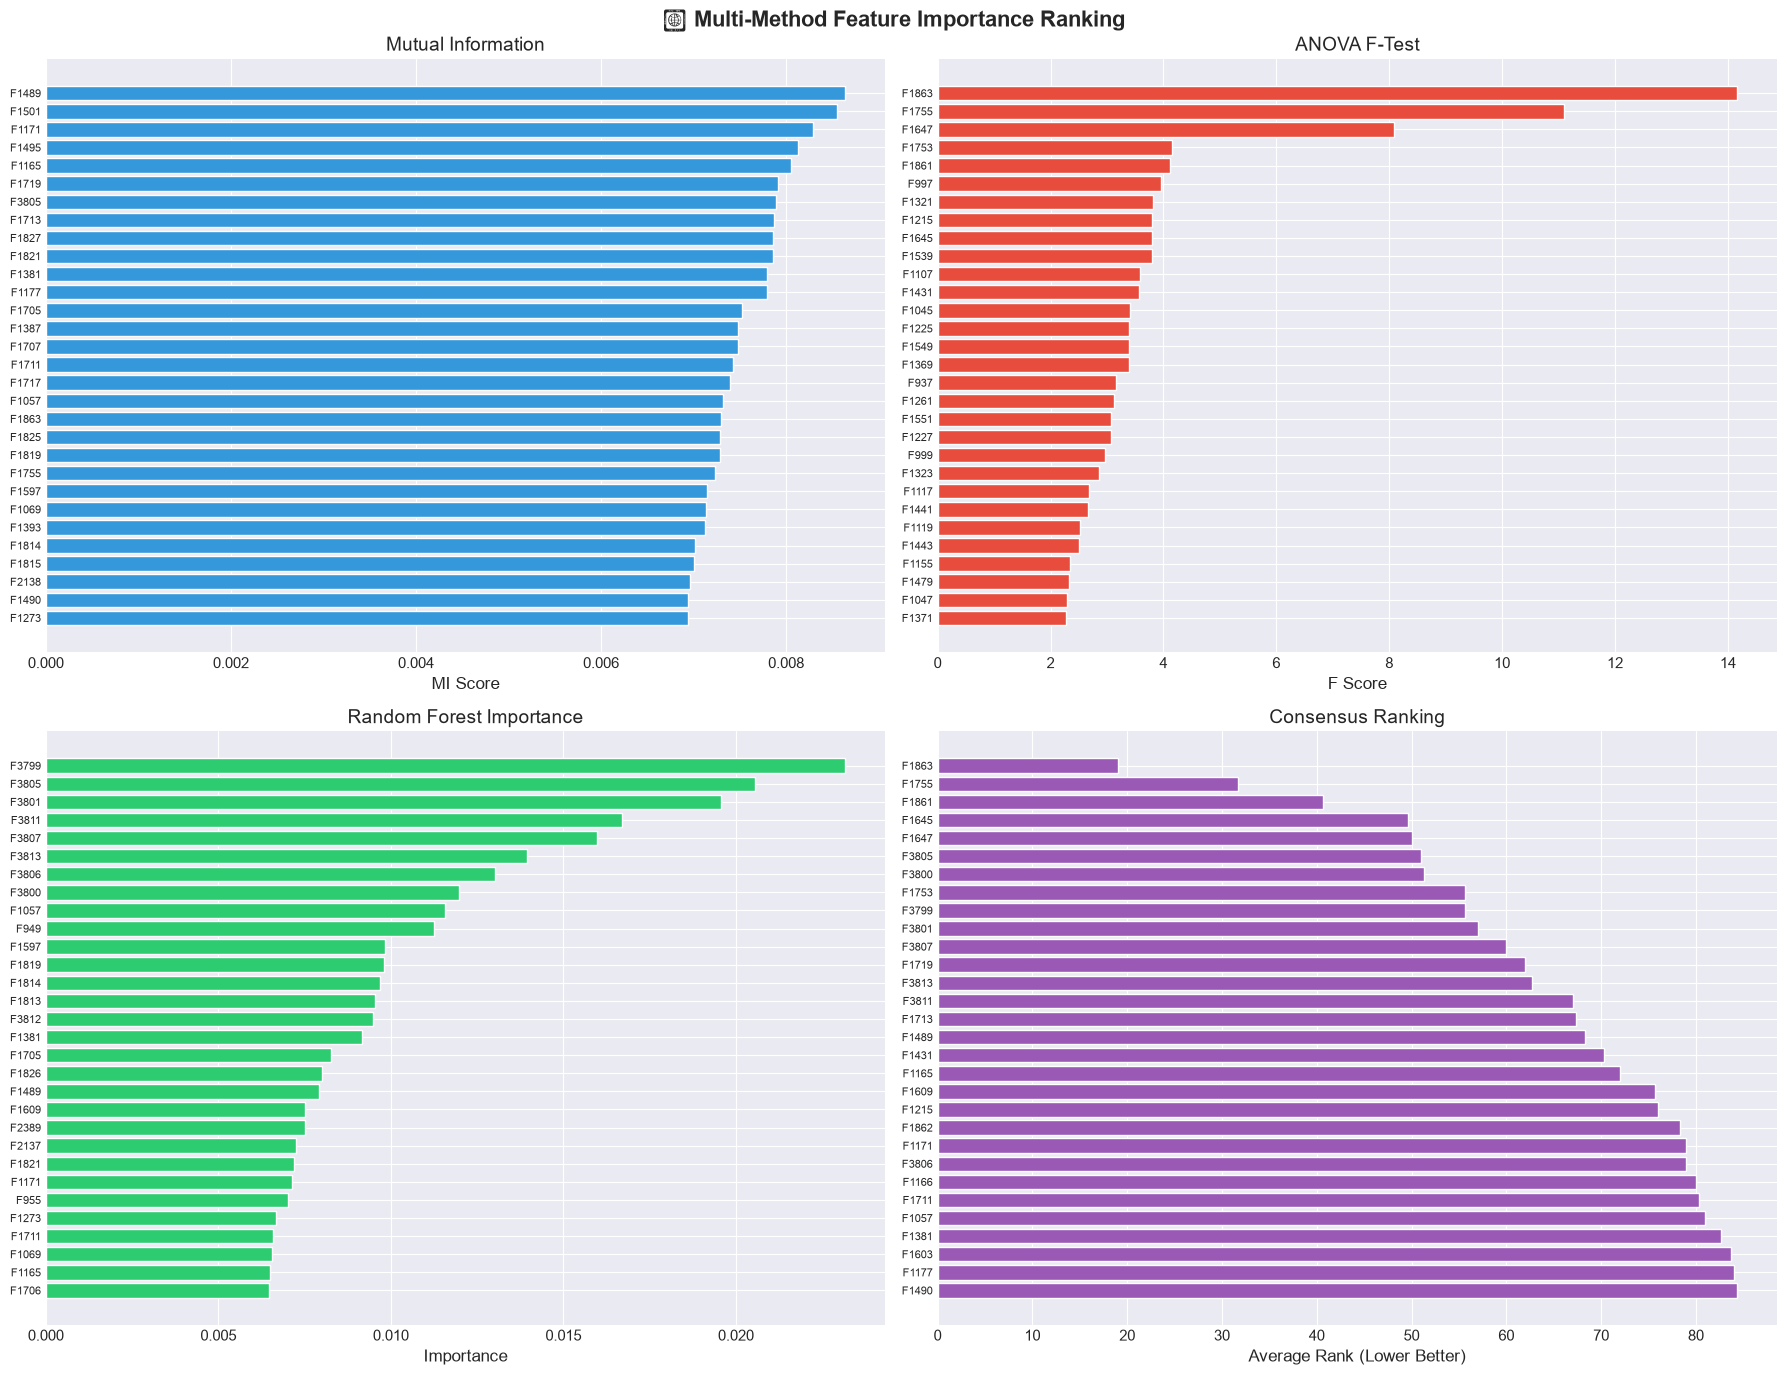


✅ TOP 20 CONSENSUS FEATURES
 1. F1863           Rank Score = 19.00
 2. F1755           Rank Score = 31.67
 3. F1861           Rank Score = 40.67
 4. F1645           Rank Score = 49.67
 5. F1647           Rank Score = 50.00
 6. F3805           Rank Score = 51.00
 7. F3800           Rank Score = 51.33
 8. F1753           Rank Score = 55.67
 9. F3799           Rank Score = 55.67
10. F3801           Rank Score = 57.00
11. F3807           Rank Score = 60.00
12. F1719           Rank Score = 62.00
13. F3813           Rank Score = 62.67
14. F3811           Rank Score = 67.00
15. F1713           Rank Score = 67.33
16. F1489           Rank Score = 68.33
17. F1431           Rank Score = 70.33
18. F1165           Rank Score = 72.00
19. F1609           Rank Score = 75.67
20. F1215           Rank Score = 76.00


In [ ]:
def visualize_feature_importance_ranking(X, y):

    print("\n" + "="*80)
    print("VISUALIZATION 6: FEATURE IMPORTANCE RANKING")
    print("="*80)

    from sklearn.feature_selection import mutual_info_classif, f_classif
    from sklearn.ensemble import RandomForestClassifier

    # ==========================================================
    # DATA CLEANING
    # ==========================================================

    X_temp = X.copy()

    X_temp = X_temp.replace([np.inf, -np.inf], np.nan)
    X_temp = X_temp.fillna(X_temp.median())

    # ==========================================================
    # FEATURE PRE-SELECTION
    # ==========================================================

    print("Selecting top variance features...")

    feature_vars = X_temp.var()

    selected_features = (
        feature_vars
        .sort_values(ascending=False)
        .head(500)
        .index
    )

    X_small = X_temp[selected_features]

    print(f"Using {len(selected_features)} features")

    # ==========================================================
    # FIGURE
    # ==========================================================

    fig = plt.figure(figsize=(18, 14))

    # ==========================================================
    # METHOD 1: MUTUAL INFORMATION
    # ==========================================================

    print("Computing Mutual Information...")

    ax1 = plt.subplot(2, 2, 1)

    mi_scores = mutual_info_classif(
        X_small,
        y,
        random_state=42,
        n_neighbors=5
    )

    mi_series = pd.Series(
        mi_scores,
        index=X_small.columns
    ).sort_values(ascending=False)

    top30_mi = mi_series.head(30)

    ax1.barh(
        range(len(top30_mi)),
        top30_mi.values,
        color='#3498db'
    )

    ax1.set_yticks(range(len(top30_mi)))
    ax1.set_yticklabels(top30_mi.index, fontsize=8)

    ax1.set_title(
        'Mutual Information'
    )

    ax1.set_xlabel(
        'MI Score'
    )

    ax1.invert_yaxis()

    # ==========================================================
    # METHOD 2: ANOVA
    # ==========================================================

    print("Computing ANOVA F-Test...")

    ax2 = plt.subplot(2, 2, 2)

    f_scores, p_values = f_classif(
        X_small,
        y
    )

    f_series = pd.Series(
        f_scores,
        index=X_small.columns
    ).sort_values(ascending=False)

    top30_f = f_series.head(30)

    ax2.barh(
        range(len(top30_f)),
        top30_f.values,
        color='#e74c3c'
    )

    ax2.set_yticks(range(len(top30_f)))
    ax2.set_yticklabels(top30_f.index, fontsize=8)

    ax2.set_title(
        'ANOVA F-Test'
    )

    ax2.set_xlabel(
        'F Score'
    )

    ax2.invert_yaxis()

    # ==========================================================
    # METHOD 3: RANDOM FOREST
    # ==========================================================

    print("Training Random Forest...")

    ax3 = plt.subplot(2, 2, 3)

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_small, y)

    rf_importance = pd.Series(
        rf.feature_importances_,
        index=X_small.columns
    ).sort_values(ascending=False)

    top30_rf = rf_importance.head(30)

    ax3.barh(
        range(len(top30_rf)),
        top30_rf.values,
        color='#2ecc71'
    )

    ax3.set_yticks(range(len(top30_rf)))
    ax3.set_yticklabels(top30_rf.index, fontsize=8)

    ax3.set_title(
        'Random Forest Importance'
    )

    ax3.set_xlabel(
        'Importance'
    )

    ax3.invert_yaxis()

    # ==========================================================
    # METHOD 4: CONSENSUS RANKING
    # ==========================================================

    print("Building consensus ranking...")

    ax4 = plt.subplot(2, 2, 4)

    consensus_scores = {}

    all_features = set(X_small.columns)

    for feat in all_features:

        mi_rank = mi_series.index.get_loc(feat)

        f_rank = f_series.index.get_loc(feat)

        rf_rank = rf_importance.index.get_loc(feat)

        consensus_scores[feat] = (
            mi_rank +
            f_rank +
            rf_rank
        ) / 3

    consensus_series = (
        pd.Series(consensus_scores)
        .sort_values()
    )

    top30_consensus = consensus_series.head(30)

    ax4.barh(
        range(len(top30_consensus)),
        top30_consensus.values,
        color='#9b59b6'
    )

    ax4.set_yticks(
        range(len(top30_consensus))
    )

    ax4.set_yticklabels(
        top30_consensus.index,
        fontsize=8
    )

    ax4.set_title(
        'Consensus Ranking'
    )

    ax4.set_xlabel(
        'Average Rank (Lower Better)'
    )

    ax4.invert_yaxis()

    # ==========================================================
    # SAVE + SHOW
    # ==========================================================

    plt.suptitle(
        '🎯 Multi-Method Feature Importance Ranking',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        '06_feature_importance_ranking.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    # ==========================================================
    # SUMMARY
    # ==========================================================

    print("\n✅ TOP 20 CONSENSUS FEATURES")

    for i, (feat, score) in enumerate(
        top30_consensus.head(20).items(),
        start=1
    ):
        print(
            f"{i:2d}. {feat:<15} Rank Score = {score:.2f}"
        )

    return (
        top30_consensus,
        mi_series,
        f_series,
        rf_importance
    )


# Run
consensus_rankings, mi_scores, f_scores, rf_importance = \
    visualize_feature_importance_ranking(
        X_clean,
        y_clean
    )